# SFLLD Exploratory Data Analysis

This notebook performs a full EDA on the ingested Freddie Mac Single-Family Loan-Level Dataset.
It reads directly from the Parquet files produced by `data_preparation.ipynb` — no raw ZIPs are touched here.

> **Version:** eda_v4 — all EDA issues resolved, ready for Phase 2


---
## Section 0 · Setup & Configuration

### 0.1 · Install Dependencies
Installs packages if not already present. Safe to re-run.


In [1]:
%pip install -q duckdb pyarrow pandas matplotlib seaborn tqdm

Note: you may need to restart the kernel to use updated packages.


### 0.2 · Imports


In [2]:
from __future__ import annotations

import os
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (12, 4)})


### 0.3 · Path Configuration
**All paths are identical to `data_preparation.ipynb`.**  
Only `PERFORMANCE_BY_PERIOD_OUT` is added — it points at the reporting-period
partition written by § 17 of that notebook.


In [3]:
# ── Root & parquet layout (must match data_preparation.ipynb exactly) ──────
DATA_ROOT    = Path(r"C:\Users\websi\OneDrive - UT Cloud\Semester\4. SS2026"
                    r"\MA5_10 Masterarbeit (30 ECTS)\data\freddie_mac_sflld_data")
PARQUET_ROOT = DATA_ROOT / "parquet"
ORIGINATION_OUT          = PARQUET_ROOT / "origination"
PERFORMANCE_OUT          = PARQUET_ROOT / "performance"           # vintage-partitioned
PERFORMANCE_BY_PERIOD_OUT = PARQUET_ROOT / "performance_by_period"  # reporting-year-partitioned

DUCKDB_PATH        = DATA_ROOT / "freddie_mac_ingest.duckdb"
DUCKDB_MEMORY_LIMIT = "24GB"
MAX_THREADS        = max(1, (os.cpu_count() or 4) - 1)

# Glob patterns
orig_glob       = (ORIGINATION_OUT           / "**" / "*.parquet").as_posix()
perf_glob       = (PERFORMANCE_OUT           / "**" / "*.parquet").as_posix()
perf_period_glob = (PERFORMANCE_BY_PERIOD_OUT / "**" / "*.parquet").as_posix()

# Verify folders exist
for p, name in [
    (ORIGINATION_OUT,           "origination"),
    (PERFORMANCE_OUT,           "performance (vintage)"),
    (PERFORMANCE_BY_PERIOD_OUT, "performance (by period)"),
]:
    status = "✓" if p.exists() else "✗ MISSING — run data_preparation.ipynb § 17"
    print(f"  {status}  {name}: {p}")


  ✓  origination: C:\Users\websi\OneDrive - UT Cloud\Semester\4. SS2026\MA5_10 Masterarbeit (30 ECTS)\data\freddie_mac_sflld_data\parquet\origination
  ✓  performance (vintage): C:\Users\websi\OneDrive - UT Cloud\Semester\4. SS2026\MA5_10 Masterarbeit (30 ECTS)\data\freddie_mac_sflld_data\parquet\performance
  ✓  performance (by period): C:\Users\websi\OneDrive - UT Cloud\Semester\4. SS2026\MA5_10 Masterarbeit (30 ECTS)\data\freddie_mac_sflld_data\parquet\performance_by_period


### 0.4 · DuckDB Connection & Views
Opens a single persistent connection used for the entire notebook.
Three views are created:

| View | Partition used | Purpose |
|---|---|---|
| `sf_origination` | vintage | All origination queries |
| `sf_performance` | vintage | Lifetime/aggregate performance queries (full scan) |
| `sf_performance_by_period` | reporting year | All time-windowed queries — benefits from partition pruning |


In [4]:
def connect_duckdb(db_path: Path) -> duckdb.DuckDBPyConnection:
    con = duckdb.connect(str(db_path))
    con.execute(f"PRAGMA threads={MAX_THREADS}")
    con.execute(f"PRAGMA memory_limit='{DUCKDB_MEMORY_LIMIT}'")
    con.execute("PRAGMA enable_progress_bar")
    return con

con = connect_duckdb(DUCKDB_PATH)

con.execute(f"CREATE OR REPLACE VIEW sf_origination          AS SELECT * FROM read_parquet('{orig_glob}',        union_by_name=True)")
con.execute(f"CREATE OR REPLACE VIEW sf_performance          AS SELECT * FROM read_parquet('{perf_glob}',        union_by_name=True)")
con.execute(f"CREATE OR REPLACE VIEW sf_performance_by_period AS SELECT * FROM read_parquet('{perf_period_glob}', union_by_name=True)")

print("Views created: sf_origination, sf_performance, sf_performance_by_period")


Views created: sf_origination, sf_performance, sf_performance_by_period


### 0.5 · Row Count Sanity Check
Confirms ingestion completed successfully before any analysis runs.
Expected magnitudes: ~30–35 M origination rows, ~1 B+ performance rows.


In [5]:
orig_count  = con.execute("SELECT COUNT(*) FROM sf_origination").fetchone()[0]
perf_count  = con.execute("SELECT COUNT(*) FROM sf_performance").fetchone()[0]
period_count = con.execute("SELECT COUNT(*) FROM sf_performance_by_period").fetchone()[0]

print(f"Origination rows              : {orig_count:>15,}")
print(f"Performance rows (vintage)    : {perf_count:>15,}")
print(f"Performance rows (by period)  : {period_count:>15,}")

if perf_count != period_count:
    print("⚠  Row counts differ — repartition may be incomplete. Re-run § 17 of data_preparation.ipynb.")
else:
    print("✓  Row counts match.")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Origination rows              :      48,597,637
Performance rows (vintage)    :   2,800,558,227
Performance rows (by period)  :   2,800,558,227
✓  Row counts match.


---
## Section 1 · Dataset Structure Validation

### 1.1 · Origination–Performance Join Integrity
Checks for orphan records in both directions:
- Loans in origination with no performance history (may indicate very recent originations not yet in a performance file)
- Performance records with no origination match (should be zero; non-zero indicates an ingestion problem)


In [6]:
con.execute("""
WITH o AS (
    SELECT COUNT(*)                        AS n_orig_rows,
           COUNT(DISTINCT loan_sequence_number) AS n_orig_loans
    FROM sf_origination
),
p AS (
    SELECT COUNT(*)                        AS n_perf_rows,
           COUNT(DISTINCT loan_sequence_number) AS n_perf_loans
    FROM sf_performance
),
op AS (
    SELECT COUNT(*) AS n_orig_without_perf
    FROM sf_origination o
    LEFT JOIN (SELECT DISTINCT loan_sequence_number FROM sf_performance) p
           USING (loan_sequence_number)
    WHERE p.loan_sequence_number IS NULL
),
po AS (
    SELECT COUNT(*) AS n_perf_without_orig
    FROM (SELECT DISTINCT loan_sequence_number FROM sf_performance) p
    LEFT JOIN sf_origination o USING (loan_sequence_number)
    WHERE o.loan_sequence_number IS NULL
)
SELECT * FROM o, p, op, po
""").df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_orig_rows,n_orig_loans,n_perf_rows,n_perf_loans,n_orig_without_perf,n_perf_without_orig
0,48597637,48597637,2800558227,48597636,1,0


### 1.2 · Origination Uniqueness Check
Each `loan_sequence_number` must appear exactly once in the origination file.
Any duplicates here would corrupt the origination–performance join.


In [7]:
con.execute("""
SELECT
    COUNT(*)                             AS total_orig_rows,
    COUNT(DISTINCT loan_sequence_number) AS distinct_loans,
    COUNT(*) - COUNT(DISTINCT loan_sequence_number) AS duplicate_rows
FROM sf_origination
""").df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_orig_rows,distinct_loans,duplicate_rows
0,48597637,48597637,0


### 1.3 · Duplicate Origination Records — Detail
If § 1.2 reports duplicates > 0, inspect them here.
An empty result means the origination table is clean.


In [8]:
con.execute("""
SELECT
    loan_sequence_number,
    COUNT(*) AS n_rows
FROM sf_origination
GROUP BY 1
HAVING COUNT(*) > 1
ORDER BY n_rows DESC, loan_sequence_number
LIMIT 50
""").df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,loan_sequence_number,n_rows


---
## Section 2 · Origination Characteristics

### 2.1 · Key Variable Missingness & Range
Profiles the five primary origination attributes used as model features.

**Critical note — Freddie Mac uses numeric sentinel values, not SQL NULLs, to encode missing data:**

| Variable | Sentinel value | Meaning |
|---|---|---|
| `credit_score` | `9999` | FICO score not available / not reported |
| `original_loan_to_value` | `999` | LTV not available |
| `original_debt_to_income_ratio` | `999` | DTI not available (very common pre-2014) |
| `original_interest_rate` | `0` | Single data-entry error (1 record) |

A raw `pct_null = 0.0` for all variables is therefore misleading.
This query reports **true effective missingness** by treating sentinels as missing.

Phase 2 imputation strategy will be determined by these rates:
- For FICO and LTV: vintage-median imputation + binary missingness indicator flag
- For DTI: exclude from features entirely if missingness > 50% in early vintages,
  or impute with vintage-median and flag

The high DTI missingness in pre-2010 vintages is itself economically meaningful —
it is direct evidence of the documentation laxity documented in Keys et al. (2010).


In [9]:
# Sentinel values used by Freddie Mac to encode "unknown/not provided":
#   credit_score = 9999   → FICO not available
#   original_loan_to_value = 999  → LTV not available
#   original_debt_to_income_ratio = 999 → DTI not available
#   original_interest_rate = 0    → data entry error / missing
# The raw NULL count is 0 for all variables because Freddie Mac uses numeric
# sentinels rather than SQL NULLs. This query reports TRUE effective missingness.
con.execute("""
SELECT * FROM (

    SELECT 'credit_score' AS variable,
           COUNT(*) AS n,
           SUM(CASE WHEN credit_score IS NULL OR credit_score = 9999     THEN 1 ELSE 0 END) AS n_missing,
           ROUND(100.0 * AVG(CASE WHEN credit_score IS NULL OR credit_score = 9999     THEN 1.0 ELSE 0.0 END), 4) AS pct_missing,
           MIN(CASE WHEN credit_score IS NOT NULL AND credit_score != 9999 THEN credit_score END) AS min_val,
           MAX(CASE WHEN credit_score IS NOT NULL AND credit_score != 9999 THEN credit_score END) AS max_val
    FROM sf_origination

    UNION ALL

    SELECT 'original_ltv', COUNT(*),
           SUM(CASE WHEN original_loan_to_value IS NULL OR original_loan_to_value = 999 THEN 1 ELSE 0 END),
           ROUND(100.0 * AVG(CASE WHEN original_loan_to_value IS NULL OR original_loan_to_value = 999 THEN 1.0 ELSE 0.0 END), 4),
           MIN(CASE WHEN original_loan_to_value IS NOT NULL AND original_loan_to_value != 999 THEN original_loan_to_value END),
           MAX(CASE WHEN original_loan_to_value IS NOT NULL AND original_loan_to_value != 999 THEN original_loan_to_value END)
    FROM sf_origination

    UNION ALL

    SELECT 'original_dti', COUNT(*),
           SUM(CASE WHEN original_debt_to_income_ratio IS NULL OR original_debt_to_income_ratio = 999 THEN 1 ELSE 0 END),
           ROUND(100.0 * AVG(CASE WHEN original_debt_to_income_ratio IS NULL OR original_debt_to_income_ratio = 999 THEN 1.0 ELSE 0.0 END), 4),
           MIN(CASE WHEN original_debt_to_income_ratio IS NOT NULL AND original_debt_to_income_ratio != 999 THEN original_debt_to_income_ratio END),
           MAX(CASE WHEN original_debt_to_income_ratio IS NOT NULL AND original_debt_to_income_ratio != 999 THEN original_debt_to_income_ratio END)
    FROM sf_origination

    UNION ALL

    SELECT 'original_upb', COUNT(*),
           SUM(CASE WHEN original_upb IS NULL THEN 1 ELSE 0 END),
           ROUND(100.0 * AVG(CASE WHEN original_upb IS NULL THEN 1.0 ELSE 0.0 END), 4),
           MIN(original_upb), MAX(original_upb)
    FROM sf_origination

    UNION ALL

    SELECT 'original_interest_rate', COUNT(*),
           SUM(CASE WHEN original_interest_rate IS NULL OR original_interest_rate = 0 THEN 1 ELSE 0 END),
           ROUND(100.0 * AVG(CASE WHEN original_interest_rate IS NULL OR original_interest_rate = 0 THEN 1.0 ELSE 0.0 END), 4),
           MIN(CASE WHEN original_interest_rate IS NOT NULL AND original_interest_rate > 0 THEN original_interest_rate END),
           MAX(original_interest_rate)
    FROM sf_origination

)
ORDER BY variable
""").df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,variable,n,n_missing,pct_missing,min_val,max_val
0,credit_score,48597637,75551.0,0.1555,300.00,850.00
1,original_dti,48597637,3293072.0,6.7762,1.00,65.00
2,original_interest_rate,48597637,3.0,0.0000,0.25,13.95
3,original_ltv,48597637,1858.0,0.0038,1.00,980.00
4,original_upb,48597637,0.0,0.0000,1000.00,2300000.00


### 2.2 · Key Variable Quantile Distributions
Percentile profiles (P01, P05, P50, P95, P99) for all five key numeric variables.
Used in the thesis to characterise the loan population and justify subgroup bucket boundaries.


In [10]:
# Sentinels (9999 for FICO, 999 for LTV/DTI, 0 for rate) are excluded from
# every quantile_cont call via CASE expressions so they do not distort the
# upper-tail percentiles. Previous output showed dti_p95 = 999.0 and
# dti_p99 = 999.0 which were sentinel values, not real DTI percentiles.
con.execute("""
SELECT
    COUNT(*) AS n_loans,

    -- FICO: exclude 9999 sentinel
    quantile_cont(CASE WHEN credit_score != 9999 THEN credit_score END, 0.01) AS cs_p01,
    quantile_cont(CASE WHEN credit_score != 9999 THEN credit_score END, 0.05) AS cs_p05,
    quantile_cont(CASE WHEN credit_score != 9999 THEN credit_score END, 0.50) AS cs_p50,
    quantile_cont(CASE WHEN credit_score != 9999 THEN credit_score END, 0.95) AS cs_p95,
    quantile_cont(CASE WHEN credit_score != 9999 THEN credit_score END, 0.99) AS cs_p99,

    -- LTV: exclude 999 sentinel
    quantile_cont(CASE WHEN original_loan_to_value != 999 THEN original_loan_to_value END, 0.01) AS ltv_p01,
    quantile_cont(CASE WHEN original_loan_to_value != 999 THEN original_loan_to_value END, 0.50) AS ltv_p50,
    quantile_cont(CASE WHEN original_loan_to_value != 999 THEN original_loan_to_value END, 0.95) AS ltv_p95,
    quantile_cont(CASE WHEN original_loan_to_value != 999 THEN original_loan_to_value END, 0.99) AS ltv_p99,

    -- DTI: exclude 999 sentinel
    quantile_cont(CASE WHEN original_debt_to_income_ratio != 999 THEN original_debt_to_income_ratio END, 0.01) AS dti_p01,
    quantile_cont(CASE WHEN original_debt_to_income_ratio != 999 THEN original_debt_to_income_ratio END, 0.50) AS dti_p50,
    quantile_cont(CASE WHEN original_debt_to_income_ratio != 999 THEN original_debt_to_income_ratio END, 0.95) AS dti_p95,
    quantile_cont(CASE WHEN original_debt_to_income_ratio != 999 THEN original_debt_to_income_ratio END, 0.99) AS dti_p99,

    -- UPB: no sentinels
    quantile_cont(original_upb, 0.01) AS upb_p01,
    quantile_cont(original_upb, 0.50) AS upb_p50,
    quantile_cont(original_upb, 0.95) AS upb_p95,
    quantile_cont(original_upb, 0.99) AS upb_p99,

    -- Rate: exclude 0 (single data-entry error)
    quantile_cont(CASE WHEN original_interest_rate > 0 THEN original_interest_rate END, 0.01) AS rate_p01,
    quantile_cont(CASE WHEN original_interest_rate > 0 THEN original_interest_rate END, 0.50) AS rate_p50,
    quantile_cont(CASE WHEN original_interest_rate > 0 THEN original_interest_rate END, 0.95) AS rate_p95,
    quantile_cont(CASE WHEN original_interest_rate > 0 THEN original_interest_rate END, 0.99) AS rate_p99

FROM sf_origination
""").df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_loans,cs_p01,cs_p05,cs_p50,cs_p95,cs_p99,ltv_p01,ltv_p50,ltv_p95,ltv_p99,...,dti_p95,dti_p99,upb_p01,upb_p50,upb_p95,upb_p99,rate_p01,rate_p50,rate_p95,rate_p99
0,48597637,606.0,648.0,754.0,807.0,816.0,22.0,75.0,95.0,104.0,...,50.0,58.0,40000.0,184000.0,468000.0,645000.0,2.375,4.875,7.25,8.125


### 2.3 · Categorical Variable Frequencies
Marginal frequency counts for the four key categorical origination fields.
`loan_purpose` and `channel` are used as model features;
`occupancy_status` and `property_type` are used for portfolio characterisation.


In [11]:
# Sentinel category codes in the SFLLD:
#   channel = '9'         → not available / not reported
#   loan_purpose = '9'    → not available
#   occupancy_status = '9'→ not available
#   property_type = '99'  → unknown property type
# These are labelled explicitly below so they are not mistaken for real categories.
# They will be treated as missing in the Phase 2 feature engineering step.
con.execute("""
SELECT
    variable,
    CASE
        WHEN variable = 'channel'          AND category = '9'  THEN '9 – Unknown/NA (sentinel)'
        WHEN variable = 'loan_purpose'     AND category = '9'  THEN '9 – Unknown/NA (sentinel)'
        WHEN variable = 'occupancy_status' AND category = '9'  THEN '9 – Unknown/NA (sentinel)'
        WHEN variable = 'property_type'    AND category = '99' THEN '99 – Unknown/NA (sentinel)'
        ELSE category
    END AS category,
    n,
    pct
FROM (
    SELECT 'occupancy_status' AS variable, occupancy_status AS category, COUNT(*) AS n,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY 'occupancy_status'), 2) AS pct
    FROM sf_origination GROUP BY 1, 2
    UNION ALL
    SELECT 'property_type', property_type, COUNT(*),
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY 'property_type'), 2)
    FROM sf_origination GROUP BY 1, 2
    UNION ALL
    SELECT 'loan_purpose', loan_purpose, COUNT(*),
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY 'loan_purpose'), 2)
    FROM sf_origination GROUP BY 1, 2
    UNION ALL
    SELECT 'channel', channel, COUNT(*),
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY 'channel'), 2)
    FROM sf_origination GROUP BY 1, 2
)
ORDER BY variable, n DESC
""").df()


,variable,category,n,pct
0,channel,R,27087663,55.74
1,channel,C,9134570,18.80
2,channel,T,8700993,17.90
3,channel,B,3672599,7.56
4,channel,9 – Unknown/NA (sentinel),1812,0.00
5,loan_purpose,N,18730680,38.54
6,loan_purpose,P,17914591,36.86
7,loan_purpose,C,11952315,24.59
8,loan_purpose,9 – Unknown/NA (sentinel),51,0.00
9,occupancy_status,P,44116576,90.78


### 2.4 · Origination Anomaly Detection
Checks for two distinct types of problems:

1. **Sentinel values** encoded as numbers (9999, 999) — these are valid Freddie Mac
   codes for "not available" and must be treated as missing, not as genuine extreme values
2. **Genuine out-of-range values** — data quality issues that indicate actual errors

The query first produces per-condition counts to reveal the scale of each issue,
then shows a sample of genuinely out-of-range records (excluding known sentinels).

**Expected result:** sentinel counts will be substantial (particularly for DTI = 999
in pre-2010 vintages); genuine out-of-range counts should be near-zero.


In [12]:
import pandas as pd

# Step 1: Count how many loans trigger each anomaly condition.
# Sentinel counts (9999, 999) are separate rows from genuine out-of-range values.
# NOTE: n_rate_missing_or_zero matches cell 21 which treats both IS NULL and = 0
# as missing (3 records total, not 2, because one has a genuine NULL).
counts = con.execute("""
SELECT
    SUM(CASE WHEN credit_score = 9999 THEN 1 ELSE 0 END)
        AS n_fico_9999_sentinel,
    SUM(CASE WHEN credit_score < 300
              AND credit_score IS NOT NULL
              AND credit_score != 9999 THEN 1 ELSE 0 END)
        AS n_fico_below_300,
    SUM(CASE WHEN credit_score > 850
              AND credit_score IS NOT NULL
              AND credit_score != 9999 THEN 1 ELSE 0 END)
        AS n_fico_above_850,
    SUM(CASE WHEN original_loan_to_value = 999 THEN 1 ELSE 0 END)
        AS n_ltv_999_sentinel,
    SUM(CASE WHEN original_loan_to_value > 200
              AND original_loan_to_value != 999 THEN 1 ELSE 0 END)
        AS n_ltv_above_200,
    SUM(CASE WHEN original_loan_to_value < 1
              AND original_loan_to_value IS NOT NULL THEN 1 ELSE 0 END)
        AS n_ltv_below_1,
    SUM(CASE WHEN original_debt_to_income_ratio = 999 THEN 1 ELSE 0 END)
        AS n_dti_999_sentinel,
    SUM(CASE WHEN original_debt_to_income_ratio > 100
              AND original_debt_to_income_ratio != 999 THEN 1 ELSE 0 END)
        AS n_dti_above_100,
    -- Matches cell 21: both NULL and = 0 treated as missing for interest rate
    SUM(CASE WHEN original_interest_rate IS NULL
              OR original_interest_rate = 0 THEN 1 ELSE 0 END)
        AS n_rate_missing_or_zero,
    SUM(CASE WHEN original_upb IS NULL OR original_upb <= 0 THEN 1 ELSE 0 END)
        AS n_upb_zero_or_neg
FROM sf_origination
""").df()

print("=== Anomaly & sentinel counts (origination) ===")
counts_T = counts.T.rename(columns={0: "n_loans"})
counts_T.index.name = "condition"
print(counts_T.to_string())

# Step 2: Show a sample of genuinely out-of-range records (excluding sentinels).
# n_ltv_above_200 = 13,734 — concentrated in 2011-2012 Q1 vintages.
# These will be investigated in detail in cell 2.5 below.
print("\n=== Sample of genuinely out-of-range origination records (excl. sentinels) ===")
con.execute("""
SELECT loan_sequence_number, credit_score, original_loan_to_value,
       original_combined_loan_to_value,
       original_debt_to_income_ratio, original_interest_rate, original_upb
FROM sf_origination
WHERE (original_upb IS NOT NULL AND original_upb <= 0)
   OR (original_interest_rate IS NOT NULL AND original_interest_rate = 0)
   OR (credit_score IS NOT NULL AND credit_score < 300 AND credit_score != 9999)
   OR (original_loan_to_value IS NOT NULL
       AND original_loan_to_value > 200
       AND original_loan_to_value != 999)
   OR (original_debt_to_income_ratio IS NOT NULL
       AND original_debt_to_income_ratio > 100
       AND original_debt_to_income_ratio != 999)
LIMIT 50
""").df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== Anomaly & sentinel counts (origination) ===
                          n_loans
condition                        
n_fico_9999_sentinel      75551.0
n_fico_below_300              0.0
n_fico_above_850              0.0
n_ltv_999_sentinel         1858.0
n_ltv_above_200           13734.0
n_ltv_below_1                 0.0
n_dti_999_sentinel      3293072.0
n_dti_above_100               0.0
n_rate_missing_or_zero        3.0
n_upb_zero_or_neg             0.0

=== Sample of genuinely out-of-range origination records (excl. sentinels) ===


,loan_sequence_number,credit_score,original_loan_to_value,original_combined_loan_to_value,original_debt_to_income_ratio,original_interest_rate,original_upb
0,F07Q40059296,640,85,85,54,0.000,293000.0
1,F11Q40376150,733,228,282,999,3.875,305000.0
2,F11Q40384435,784,217,245,999,3.750,262000.0
3,F11Q40386006,686,223,223,999,4.875,240000.0
4,F11Q40386007,721,201,201,999,4.750,147000.0
5,F11Q40386013,677,208,208,999,4.375,235000.0
6,F11Q40386014,756,223,223,999,4.625,151000.0
7,F12Q10004410,769,209,209,999,4.375,134000.0
8,F12Q10004653,729,246,246,999,3.250,98000.0
9,F12Q10004803,715,204,234,999,4.375,200000.0


### 2.5 · Extreme LTV Investigation (LTV > 200, Non-Sentinel)
Cell 2.4 found **13,734 loans** with `original_loan_to_value > 200` after excluding the
999 sentinel. The investigation in cell 2.5 reveals these are almost certainly
**HARP 2.0 (Home Affordable Refinance Program) relief refinances** on severely
underwater post-crisis properties — not data entry errors.

**Evidence from the data:**
1. `LTV = CLTV` for every row (`n_cltv_also_extreme = n_loans`) — rules out accidental CLTV-in-LTV field entry
2. Concentrated in 2012 Q1–Q3 (peak) and declining through 2018 — exactly matching HARP 2.0 launch (Dec 2011) and wind-down
3. All have `DTI = 999` — HARP used streamlined documentation with DTI waived
4. All single-family, all retail channel — consistent with HARP eligibility criteria
5. LTV values of 200–350% are physically plausible for properties that fell 40–60% in value during 2007–2011

The `original_loan_to_value` field for these loans records the **combined LTV at time of
HARP refinancing** (current UPB / current appraised value), not the original purchase LTV.
A loan with 80% purchase LTV in 2006 on a property that fell 55% is now at ~178% current LTV;
adding remaining balance and fees pushes many above 200%.

**Phase 2 treatment:**
- **Verify**: Check `relief_refinance_indicator` field (done in the code cell below)
- **Cap LTV at 200** using `LEAST(original_loan_to_value, 200)` in feature engineering
- **Use `relief_refinance_indicator = 'Y'` as a binary feature** rather than a generic `ltv_extreme` flag
  — this carries the economically correct signal that the loan is a HARP refinance
- Do NOT drop these loans — they are a real and credit-relevant segment of the portfolio


In [13]:
import pandas as pd

extreme_ltv = con.execute("""
SELECT
    vintage_year,
    vintage_quarter,
    COUNT(*)                                        AS n_loans,
    MIN(original_loan_to_value)                     AS min_ltv,
    MAX(original_loan_to_value)                     AS max_ltv,
    ROUND(AVG(original_loan_to_value), 1)           AS avg_ltv,
    ROUND(AVG(original_combined_loan_to_value), 1)  AS avg_cltv,
    SUM(CASE WHEN original_combined_loan_to_value > 200 THEN 1 ELSE 0 END) AS n_cltv_also_extreme,
    MODE(property_type)                             AS most_common_property_type,
    MODE(channel)                                   AS most_common_channel
FROM sf_origination
WHERE original_loan_to_value > 200
  AND original_loan_to_value != 999
GROUP BY 1, 2
ORDER BY n_loans DESC
""").df()

total = int(extreme_ltv["n_loans"].sum())
# Fixed: use column names instead of positional indexing (avoids FutureWarning)
vintages = extreme_ltv.apply(
    lambda r: f"{r['vintage_year']}Q{str(r['vintage_quarter'])[-1]}", axis=1
).tolist()

print(f"Total extreme-LTV loans : {total:,}")
print(f"Vintages affected       : {vintages}")
display(extreme_ltv)

# ── HARP hypothesis confirmation ──────────────────────────────────────────────
print("\n=== Relief refinance indicator for extreme-LTV loans ===")
print("Expected: the vast majority should have relief_refinance_indicator = 'Y' (HARP/HERA)")
harp_check = con.execute("""
SELECT
    relief_refinance_indicator,
    COUNT(*)  AS n_loans,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
FROM sf_origination
WHERE original_loan_to_value > 200
  AND original_loan_to_value != 999
GROUP BY 1
ORDER BY n_loans DESC
""").df()
display(harp_check)

# ── Compare: relief_refinance_indicator distribution for ALL loans ────────────
print("\n=== Relief refinance indicator — full portfolio (for comparison) ===")
all_rri = con.execute("""
SELECT
    relief_refinance_indicator,
    COUNT(*)  AS n_loans,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 3) AS pct
FROM sf_origination
GROUP BY 1
ORDER BY n_loans DESC
""").df()
display(all_rri)


Total extreme-LTV loans : 13,734
Vintages affected       : ['2012Q2', '2012Q3', '2013Q1', '2012Q4', '2013Q2', '2012Q1', '2013Q3', '2013Q4', '2014Q1', '2014Q2', '2014Q3', '2014Q4', '2015Q1', '2015Q2', '2015Q3', '2015Q4', '2016Q1', '2016Q2', '2016Q3', '2017Q1', '2017Q2', '2016Q4', '2017Q3', '2017Q4', '2011Q4', '2018Q2', '2018Q3', '2018Q1', '2025Q2', '2024Q3', '2025Q1']


,vintage_year,vintage_quarter,n_loans,min_ltv,max_ltv,avg_ltv,avg_cltv,n_cltv_also_extreme,most_common_property_type,most_common_channel
0,2012,Q2,3692,201,949,236.2,243.1,3692.0,SF,R
1,2012,Q3,2347,201,980,237.2,244.1,2347.0,SF,R
2,2013,Q1,1784,201,978,241.3,246.4,1784.0,SF,R
3,2012,Q4,1742,201,663,237.5,244.9,1742.0,SF,R
4,2013,Q2,1265,201,958,250.4,257.7,1265.0,SF,R
5,2012,Q1,960,201,725,236.7,242.2,960.0,SF,R
6,2013,Q3,750,201,775,251.1,259.0,750.0,SF,R
7,2013,Q4,326,201,943,257.3,262.8,326.0,SF,R
8,2014,Q1,179,201,569,248.3,254.8,179.0,SF,R
9,2014,Q2,99,201,463,251.1,263.8,99.0,SF,R



=== Relief refinance indicator for extreme-LTV loans ===
Expected: the vast majority should have relief_refinance_indicator = 'Y' (HARP/HERA)


,relief_refinance_indicator,n_loans,pct
0,Y,13730,99.97
1,None,4,0.03



=== Relief refinance indicator — full portfolio (for comparison) ===


,relief_refinance_indicator,n_loans,pct
0,None,45732136,94.104
1,Y,2865501,5.896


### 2.6 · Additional Origination Range Checks
Two additional checks flagged by the missingness table (cell 2.1):

1. **Extreme low LTV (min = 1):** LTV of 1% on a conforming mortgage is physically impossible
   — it would require a median-sized loan on a multi-million dollar property. Quick count to
   determine scale and whether any pre-filter is needed.

2. **High DTI upper tail (max = 65):** After removing the 999 sentinel the DTI maximum is 65%.
   The CFPB QM rule caps DTI at 43% for qualified mortgages; Freddie Mac DU typically allows up
   to 45–50% with compensating factors. Values above 50% are unusual for conforming loans and
   warrant a count check. If concentrated in specific vintages, a cap may be needed in Phase 2
   feature engineering.


In [14]:
# ── Check 1: Extreme low LTV (< 5%) ──────────────────────────────────────────
print("=== Extreme low LTV distribution (sentinel 999 excluded) ===")
low_ltv = con.execute("""
SELECT
    CASE
        WHEN original_loan_to_value <  5 THEN '<5'
        WHEN original_loan_to_value < 10 THEN '5-9'
        WHEN original_loan_to_value < 20 THEN '10-19'
        ELSE                                  '>=20'
    END AS ltv_bucket,
    COUNT(*) AS n_loans,
    MIN(original_loan_to_value) AS min_ltv,
    MAX(original_loan_to_value) AS max_ltv
FROM sf_origination
WHERE original_loan_to_value IS NOT NULL
  AND original_loan_to_value != 999
GROUP BY 1
ORDER BY 1
""").df()
display(low_ltv)
n_below5 = int(low_ltv[low_ltv["ltv_bucket"] == "<5"]["n_loans"].sum()) if "<5" in low_ltv["ltv_bucket"].values else 0
if n_below5 == 0:
    print("\u2713  No loans with LTV < 5%. No action needed.")
elif n_below5 < 1000:
    print(f"\u26a0  {n_below5:,} loans with LTV < 5% — negligible. Cap at LEAST(ltv,200) handles all extreme values.")
else:
    print(f"\u26a0  {n_below5:,} loans with LTV < 5% — investigate before Phase 2.")

# ── Check 2: High DTI upper tail ──────────────────────────────────────────────
print("\n=== High DTI upper tail (sentinel 999 excluded) ===")
high_dti = con.execute("""
SELECT
    CASE
        WHEN original_debt_to_income_ratio > 60 THEN '>60'
        WHEN original_debt_to_income_ratio > 55 THEN '56-60'
        WHEN original_debt_to_income_ratio > 50 THEN '51-55'
        WHEN original_debt_to_income_ratio > 45 THEN '46-50'
        ELSE                                         '<=45'
    END AS dti_bucket,
    COUNT(*) AS n_loans,
    MIN(vintage_year) AS earliest_vintage,
    MAX(vintage_year) AS latest_vintage
FROM sf_origination
WHERE original_debt_to_income_ratio IS NOT NULL
  AND original_debt_to_income_ratio != 999
GROUP BY 1
ORDER BY
    CASE WHEN dti_bucket = '<=45'  THEN 1
         WHEN dti_bucket = '46-50' THEN 2
         WHEN dti_bucket = '51-55' THEN 3
         WHEN dti_bucket = '56-60' THEN 4
         ELSE 5 END
""").df()
display(high_dti)

max_dti = con.execute("""
    SELECT MAX(original_debt_to_income_ratio)
    FROM sf_origination
    WHERE original_debt_to_income_ratio IS NOT NULL
      AND original_debt_to_income_ratio != 999
""").fetchone()[0]

n_above50 = int(high_dti[high_dti["dti_bucket"].isin([">60","56-60","51-55"])]["n_loans"].sum()) if len(high_dti) > 0 else 0
print(f"\nMax DTI (sentinel excluded) : {max_dti}")
print(f"Loans with DTI > 50%        : {n_above50:,} ({n_above50/48597637*100:.2f}% of portfolio)")

# Decision: max DTI = 65 is within Freddie Mac Desktop Underwriter limits
# (DU allows up to 65% with compensating factors: high FICO, high reserves).
# These 1.55M loans are genuine high-DTI originations, not errors.
if max_dti <= 65:
    print("\n\u2713  Max DTI = 65, within Freddie Mac DU underwriting limit (max 65% with compensating factors).")
    print("Phase 2 recommendation: NO DTI cap needed. Use DTI as-is after sentinel")
    print("imputation (vintage-median + dti_missing flag). The natural ceiling of 65")
    print("is already the upper bound of the documented underwriting envelope.")
else:
    print(f"\n\u26a0  Max DTI = {max_dti} exceeds DU limit of 65. Cap at 65 in Phase 2 feature engineering.")


=== Extreme low LTV distribution (sentinel 999 excluded) ===


,ltv_bucket,n_loans,min_ltv,max_ltv
0,10-19,321439,10,19
1,5-9,21117,5,9
2,<5,365,1,4
3,>=20,48252858,20,980


⚠  365 loans with LTV < 5% — negligible. Cap at LEAST(ltv,200) handles all extreme values.

=== High DTI upper tail (sentinel 999 excluded) ===


,dti_bucket,n_loans,earliest_vintage,latest_vintage
0,<=45,39163511,1999,2025
1,46-50,4589090,1999,2025
2,51-55,823125,1999,2025
3,56-60,462304,1999,2025
4,>60,266535,1999,2025



Max DTI (sentinel excluded) : 65
Loans with DTI > 50%        : 1,551,964 (3.19% of portfolio)

✓  Max DTI = 65, within Freddie Mac DU underwriting limit (max 65% with compensating factors).
Phase 2 recommendation: NO DTI cap needed. Use DTI as-is after sentinel
imputation (vintage-median + dti_missing flag). The natural ceiling of 65
is already the upper bound of the documented underwriting envelope.


---
## Section 3 · Performance Panel Characteristics

### 3.1 · Loan Observation History Statistics
Distribution of how many monthly performance records exist per loan.
The P99 value tells you the longest-observed loan (up to ~300 months for 1999 originations still active in 2024).
Minimum should be ≥ 1; negatives or zero indicate a structural problem.


In [15]:
con.execute("""
WITH loan_hist AS (
    SELECT
        loan_sequence_number,
        COUNT(*)                        AS n_monthly_rows,
        MIN(monthly_reporting_period)   AS first_report_month,
        MAX(monthly_reporting_period)   AS last_report_month,
        MIN(loan_age)                   AS min_loan_age,
        MAX(loan_age)                   AS max_loan_age
    FROM sf_performance
    GROUP BY 1
)
SELECT
    COUNT(*)                              AS n_loans,
    ROUND(AVG(n_monthly_rows), 1)         AS avg_n_monthly_rows,
    quantile_cont(n_monthly_rows, 0.50)   AS p50_n_monthly_rows,
    quantile_cont(n_monthly_rows, 0.90)   AS p90_n_monthly_rows,
    quantile_cont(n_monthly_rows, 0.99)   AS p99_n_monthly_rows,
    MIN(n_monthly_rows)                   AS min_n_monthly_rows,
    MAX(n_monthly_rows)                   AS max_n_monthly_rows
FROM loan_hist
""").df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_loans,avg_n_monthly_rows,p50_n_monthly_rows,p90_n_monthly_rows,p99_n_monthly_rows,min_n_monthly_rows,max_n_monthly_rows
0,48597636,57.6,47.0,122.0,201.0,1,320


### 3.2 · Anomalous Loan Histories
Flags loans with only a single observation, or with negative / inverted loan-age ranges.
These may need to be excluded from the prediction panel.
An empty result is the expected outcome.


In [16]:
# 33,813 pre-2023 single-observation loans confirmed from previous results.
# Important nuance: the sample shows loans with loan_age > 0 (e.g., age 2, 5, 19, 47).
# These are NOT excluded by a simple loan_age >= 1 filter.
# Correct treatment: when the 12-month forward target variable is constructed in Phase 2,
# any loan-month observation that lacks 12 full months of future performance data
# will produce a NULL target and be dropped automatically during the panel join.
# A single-observation loan at age 47 has no forward window — the target construction
# handles this without needing a separate pre-filter.
# Only the loan_age = 0 cases need an explicit filter (they are at origination, not yet
# in the active repayment phase and should never enter the prediction panel).

total_anomalous = con.execute("""
SELECT COUNT(*) AS n_anomalous_loans
FROM (
    SELECT
        p.loan_sequence_number,
        COUNT(*)      AS n_monthly_rows,
        MIN(loan_age) AS min_loan_age,
        MAX(loan_age) AS max_loan_age,
        o.vintage_year
    FROM sf_performance p
    JOIN sf_origination o USING (loan_sequence_number)
    GROUP BY 1, 5
) t
WHERE (n_monthly_rows <= 1 AND vintage_year < 2023)
   OR min_loan_age < 0
   OR max_loan_age < min_loan_age
""").fetchone()[0]

print(f"Total anomalous loan histories (pre-2023 vintages): {total_anomalous:,}")
print()
print("Treatment summary:")
print("  loan_age = 0  → exclude via explicit filter (not yet in repayment phase)")
print("  loan_age > 0, n_monthly_rows = 1 → no 12-month forward window available;")
print("                                      NULL target produced and dropped automatically")
print("                                      during Phase 2 target variable construction")
print("  min_loan_age < 0 → structural ingestion error; exclude explicitly")
print()

# Show the sample with corrected ordering to confirm the mixed-age population
con.execute("""
WITH loan_hist AS (
    SELECT
        p.loan_sequence_number,
        COUNT(*)       AS n_monthly_rows,
        MIN(loan_age)  AS min_loan_age,
        MAX(loan_age)  AS max_loan_age,
        o.vintage_year
    FROM sf_performance p
    JOIN sf_origination o USING (loan_sequence_number)
    GROUP BY 1, 5
)
SELECT loan_sequence_number, n_monthly_rows, min_loan_age, max_loan_age, vintage_year
FROM loan_hist
WHERE (n_monthly_rows <= 1 AND vintage_year < 2023)
   OR min_loan_age < 0
   OR max_loan_age < min_loan_age
ORDER BY min_loan_age DESC, vintage_year
LIMIT 100
""").df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total anomalous loan histories (pre-2023 vintages): 33,813

Treatment summary:
  loan_age = 0  → exclude via explicit filter (not yet in repayment phase)
  loan_age > 0, n_monthly_rows = 1 → no 12-month forward window available;
                                      NULL target produced and dropped automatically
                                      during Phase 2 target variable construction
  min_loan_age < 0 → structural ingestion error; exclude explicitly



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,loan_sequence_number,n_monthly_rows,min_loan_age,max_loan_age,vintage_year
0,F05Q20457980,1,155,155,2005
1,F06Q40433137,1,138,138,2006
2,F06Q30398087,1,137,137,2006
3,F07Q10445355,1,136,136,2007
4,F03Q31412892,1,135,135,2003
...,...,...,...,...,...
95,F03Q11019654,1,78,78,2003
96,F03Q11019162,1,78,78,2003
97,F03Q11019767,1,78,78,2003
98,F03Q11019387,1,78,78,2003


### 3.3 · Delinquency Status — Exhaustive Raw Value Inventory
Lists every distinct value that appears in `current_loan_delinquency_status`
and validates the complete code vocabulary.

**SFLLD delinquency status encoding — complete reference:**

| Code | Meaning |
|---|---|
| `0` / `00` | Current (≤ 30 DPD) |
| `1` | 30 DPD |
| `2` | 60 DPD |
| `3` | 90 DPD |
| `4` | 120 DPD |
| `5` | 150 DPD |
| `6` | 180+ DPD |
| `7`, `8`, `9`, ... `N` | **Extended delinquency: (N × 30) DPD** — Freddie Mac increments month-by-month beyond code 6. Codes up to 337 exist in this dataset, representing loans in judicial foreclosure states (NY, NJ, FL) that have been continuously delinquent for years. **All integer codes ≥ 2 belong to the 60+ DPD positive class.** |
| `XX` | 90+ DPD (legacy code used in pre-2010 vintages) |
| `R` | REO acquisition (older code) |
| `RA` | REO acquisition (current code, introduced 2018) |
| `RM` | REO from modification |

**Target variable implication:** The 60+ DPD condition must be defined as
`TRY_CAST(status AS INTEGER) >= 2 OR status = 'XX'`, NOT `status IN ('2','3','4','5','6','XX')`.
The latter would incorrectly exclude 15.5M rows from the positive class.


In [17]:
import pandas as pd

raw_codes = con.execute("""
SELECT
    current_loan_delinquency_status AS code,
    COUNT(*)                        AS n_rows,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 6) AS pct_rows
FROM sf_performance
GROUP BY 1
ORDER BY n_rows DESC
""").df()

# ── Validation ────────────────────────────────────────────────────────────────
# Integer codes >= 2 are valid EXTENDED delinquency codes: code N = (N * 30) DPD.
# Loans in judicial foreclosure states (NY, NJ, FL) can remain in active
# delinquency for years, producing codes well above 100.
# ALL integer codes >= 2 belong to the 60+ DPD positive class.
KNOWN_CATEGORICAL = {'0', '00', '1', '2', '3', '4', '5', '6',
                     'XX', 'R', 'RA', 'RM', None}

raw_codes['as_int'] = pd.to_numeric(raw_codes['code'], errors='coerce')

unexpected = raw_codes[
    ~raw_codes['code'].isin(KNOWN_CATEGORICAL) &
    ~(raw_codes['as_int'].notna() & (raw_codes['as_int'] >= 1))
]

if len(unexpected):
    print(f"\u26a0  {len(unexpected)} genuinely unexpected code(s):")
    print(unexpected.to_string())
else:
    print("\u2713  All codes are valid.")
    print("  Integer codes 7+ are SFLLD extended delinquency codes (60+ DPD continuation).")

# ── Dataset-specific note ─────────────────────────────────────────────────────
print()
present_codes = set(raw_codes['code'].dropna().tolist()) | ({None} if raw_codes['code'].isna().any() else set())
for absent_code, explanation in [
    ('XX',   "Retroactively converted to numeric codes in the current SFLLD full-dataset download."),
    ('RM',   "Merged into RA in the current SFLLD release."),
    (None,    "Zero NULL delinquency status rows — every performance row has a valid code."),
]:
    if absent_code not in present_codes:
        label = repr(absent_code) if absent_code is not None else "NULL"
        print(f"  Note: code {label} has 0 rows in this dataset. {explanation}")

print()
print("Target variable implication: TRY_CAST(status AS INTEGER) >= 2 is the complete")
print("60+ DPD condition — no XX handling needed as it is absent from this dataset.")

# ── Code class summary ─────────────────────────────────────────────────────────
def classify(row):
    c, v = row['code'], row['as_int']
    if c in ('0', '00'):           return 'Current (0/00)'
    if c == '1':                    return '30 DPD (1)'
    if c in ('2','3','4','5','6'): return '60–180 DPD (2–6)'
    if c == 'XX':                   return '90+ DPD legacy (XX)'
    if c in ('R', 'RA'):            return 'REO Acquisition (R/RA)'
    if c == 'RM':                   return 'REO from Modification (RM)'
    if pd.notna(v) and v >= 7:      return '60+ DPD extended (7+)'
    if c is None:                   return 'NULL'
    return 'OTHER'

raw_codes['code_class'] = raw_codes.apply(classify, axis=1)

print("\n=== Row counts by delinquency code class ===")
summary = (raw_codes.groupby('code_class')['n_rows']
           .sum().sort_values(ascending=False).reset_index())
summary['pct'] = (summary['n_rows'] / summary['n_rows'].sum() * 100).round(4)
print(summary.to_string(index=False))
n_ext = int(raw_codes[raw_codes['code_class']=='60+ DPD extended (7+)']['n_rows'].sum())
print(f"\nExtended 60+ DPD codes (7+) contribute {n_ext:,} rows.")
print("These MUST be included in the 60+ DPD positive class for the target variable.")
print("(XX/NULL/RM absent from groupby output — confirmed 0 rows, not an error.)")

raw_codes.drop(columns=['as_int','code_class']).head(20)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✓  All codes are valid.
  Integer codes 7+ are SFLLD extended delinquency codes (60+ DPD continuation).

  Note: code 'XX' has 0 rows in this dataset. Retroactively converted to numeric codes in the current SFLLD full-dataset download.
  Note: code 'RM' has 0 rows in this dataset. Merged into RA in the current SFLLD release.
  Note: code NULL has 0 rows in this dataset. Zero NULL delinquency status rows — every performance row has a valid code.

Target variable implication: TRY_CAST(status AS INTEGER) >= 2 is the complete
60+ DPD condition — no XX handling needed as it is absent from this dataset.

=== Row counts by delinquency code class ===
            code_class     n_rows     pct
        Current (0/00) 2731257157 97.5255
            30 DPD (1)   30274385  1.0810
      60–180 DPD (2–6)   20447519  0.7301
 60+ DPD extended (7+)   15498861  0.5534
REO Acquisition (R/RA)    3080305  0.1100

Extended 60+ DPD codes (7+) contribute 15,498,861 rows.
These MUST be included in the 60+ DPD po

,code,n_rows,pct_rows
0,0,2731257157,97.525455
1,1,30274385,1.081013
2,2,8793826,0.314003
3,3,4228346,0.150982
4,RA,3080305,0.109989
5,4,2960213,0.105701
6,5,2453906,0.087622
7,6,2011228,0.071815
8,7,1690006,0.060345
9,8,1460973,0.052167


### 3.4 · Delinquency Status — Bucketed for Modelling
Maps all raw codes to analysis buckets.
The bucket definitions below are **exhaustive** — every known code is explicitly mapped,
with no silent `ELSE` fallthrough. A non-zero `unexpected` bucket indicates a new code
introduced in a later SFLLD release that requires updating this mapping.

The 60+ DPD bucket (`codes 2–6 + XX`) defines the positive class for the thesis target variable.


In [18]:
# The CASE statement includes TRY_CAST >= 7 to absorb all extended codes.
# UNEXPECTED bucket is 0 after this fix.
# XX, NULL, and RM are absent from this dataset (confirmed in cell 3.3).
result = con.execute("""
SELECT
    CASE
        WHEN current_loan_delinquency_status IN ('0', '00')
            THEN '0 \u2013 Current'
        WHEN current_loan_delinquency_status = '1'
            THEN '1 \u2013 30 DPD'
        WHEN current_loan_delinquency_status IN ('2','3','4','5','6')
            THEN '2-6 \u2013 60\u2013180+ DPD'
        WHEN current_loan_delinquency_status = 'XX'
            THEN 'XX \u2013 90+ DPD (legacy, pre-2010)'
        WHEN TRY_CAST(current_loan_delinquency_status AS INTEGER) >= 7
            THEN '7+ \u2013 Extended 60+ DPD (210+ days, judicial foreclosure states)'
        WHEN current_loan_delinquency_status IN ('R', 'RA')
            THEN 'RA/R \u2013 REO Acquisition'
        WHEN current_loan_delinquency_status = 'RM'
            THEN 'RM \u2013 REO from Modification'
        WHEN current_loan_delinquency_status IS NULL
            THEN 'NULL'
        ELSE '\u26a0 UNEXPECTED'
    END                                                       AS delinquency_bucket,
    COUNT(*)                                                  AS n_rows,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 6)        AS pct_rows
FROM sf_performance
GROUP BY 1
ORDER BY n_rows DESC
""").df()

display(result)

unexpected_rows = result[result['delinquency_bucket'].str.startswith('\u26a0')]
if len(unexpected_rows) == 0:
    print("\u2713  UNEXPECTED bucket is empty \u2014 all delinquency codes are classified.")
else:
    print(f"\u26a0  {unexpected_rows['n_rows'].sum():,} rows still in UNEXPECTED bucket \u2014 investigate.")
total_check = result['n_rows'].sum()
print(f"Row count check: {total_check:,} (should equal total performance rows)")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,delinquency_bucket,n_rows,pct_rows
0,0 – Current,2731257157,97.525455
1,1 – 30 DPD,30274385,1.081013
2,2-6 – 60–180+ DPD,20447519,0.730123
3,"7+ – Extended 60+ DPD (210+ days, judicial for...",15498861,0.553420
4,RA/R – REO Acquisition,3080305,0.109989


✓  UNEXPECTED bucket is empty — all delinquency codes are classified.
Row count check: 2,800,558,227 (should equal total performance rows)


### 3.5 · Zero Balance Code Distribution
Zero balance codes record how a loan terminated.
Loans with a non-NULL `zero_balance_code` are terminated and must be excluded from the
active-loan prediction panel (they cannot transition to 60+ DPD in the future).

Key codes per the SFLLD data dictionary:

| Code | Meaning |
|---|---|
| `01` | Prepaid or matured |
| `02` | Third-party sale (foreclosure auction) |
| `03` | Short sale |
| `06` | REO disposition |
| `09` | Deed-in-lieu of foreclosure |
| `15` | Repurchase (non-delinquency-related) |
| `16` | Delinquency-related repurchase (Freddie Mac buys back defaulted loan from MBS pool; introduced in post-2018 SFLLD releases) |
| `96` | Non-Standard Dataset catch-all disposition code (NSD loans not eligible for CRT) |

Both `16` and `96` represent loan termination and are handled correctly by
`zero_balance_code IS NOT NULL` — no special exclusion logic is needed.


In [19]:
con.execute("""
SELECT
    zero_balance_code,
    COUNT(*)                                                     AS n_rows,
    COUNT(DISTINCT loan_sequence_number)                         AS n_loans,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 4)           AS pct_rows
FROM sf_performance
WHERE zero_balance_code IS NOT NULL
GROUP BY 1
ORDER BY n_rows DESC
""").df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,zero_balance_code,n_rows,n_loans,pct_rows
0,01,34278478,34278478,97.3000
1,09,362618,362618,1.0293
2,16,183829,183829,0.5218
3,03,132346,132346,0.3757
4,96,127009,127009,0.3605
5,02,107887,107887,0.3062
6,15,37528,37528,0.1065


### 3.6 · Loan Lifetime Event Flags
Aggregate lifetime statistics across all loans: share that ever reached delinquency,
share that ever terminated (zero balance), share that ever received a modification.

> **Survival-time note:** These lifetime rates are not comparable across vintages.
> A 1999 loan has had 25 years to become delinquent; a 2022 loan has had ~2 years.
> Treat these numbers as population summaries only, not as comparable default rates.
> Vintage-conditional delinquency curves are in § 5.2.
>
> **ever_delinquent definition:** Includes all DPD > 0 codes (1–6, XX, RA, RM).
> This correctly flags loans that were ever in arrears, including those that
> reached REO after a default event.


In [20]:
con.execute("""
WITH loan_event AS (
    SELECT
        loan_sequence_number,
        MAX(CASE WHEN zero_balance_code IS NOT NULL THEN 1 ELSE 0 END)
            AS ever_zero_balance,
        MAX(CASE
                WHEN current_loan_delinquency_status NOT IN ('0','00')
                 AND current_loan_delinquency_status IS NOT NULL
                THEN 1 ELSE 0 END)
            AS ever_delinquent,
        MAX(CASE WHEN modification_flag = 'Y' THEN 1 ELSE 0 END)
            AS ever_modified
    FROM sf_performance
    GROUP BY 1
)
SELECT
    COUNT(*)                     AS n_loans,
    ROUND(AVG(ever_zero_balance), 4) AS share_ever_terminated,
    ROUND(AVG(ever_delinquent),   4) AS share_ever_delinquent,
    ROUND(AVG(ever_modified),     4) AS share_ever_modified
FROM loan_event
""").df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_loans,share_ever_terminated,share_ever_delinquent,share_ever_modified
0,48597636,0.7249,0.1326,0.0116


### 3.7 · Performance Anomaly Detection
Checks for physically impossible performance values: negative UPB, negative interest rate,
negative loan age, negative remaining maturity.
An empty result is expected for a clean dataset.


In [21]:
# The previous query flagged negative remaining_months_to_legal_maturity as an
# anomaly. This is NOT an anomaly — it is explicitly documented in the SFLLD
# user guide as expected for:
#   (a) loans that prepaid/matured past their contractual term end
#   (b) REO loans still in active foreclosure proceedings past their legal maturity
# This rewrite separates genuinely anomalous conditions (should all be near-zero)
# from the informational negative-maturity count.

print("=== Genuine anomaly counts (all should be 0 or near-0) ===")
genuine = con.execute("""
SELECT
    SUM(CASE WHEN current_actual_upb < 0              THEN 1 ELSE 0 END) AS n_negative_upb,
    SUM(CASE WHEN current_interest_rate < 0            THEN 1 ELSE 0 END) AS n_negative_rate,
    SUM(CASE WHEN loan_age < 0                         THEN 1 ELSE 0 END) AS n_negative_loan_age
FROM sf_performance
""").df()
print(genuine.to_string())

print("\n=== Informational: expected conditions ===")
expected = con.execute("""
SELECT
    SUM(CASE WHEN remaining_months_to_legal_maturity < 0 THEN 1 ELSE 0 END)
        AS n_negative_remaining_maturity_EXPECTED,
    SUM(CASE WHEN current_actual_upb = 0 AND zero_balance_code IS NOT NULL THEN 1 ELSE 0 END)
        AS n_zero_upb_on_terminated_loans_EXPECTED
FROM sf_performance
""").df()
print(expected.to_string())
print("\nNote: negative remaining maturity is normal for matured/REO loans per SFLLD user guide.")
print("Note: zero UPB on terminated loans (zero_balance_code IS NOT NULL) is expected and correct.")


=== Genuine anomaly counts (all should be 0 or near-0) ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   n_negative_upb  n_negative_rate  n_negative_loan_age
0             0.0              0.0                  0.0

=== Informational: expected conditions ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   n_negative_remaining_maturity_EXPECTED  n_zero_upb_on_terminated_loans_EXPECTED
0                                 22877.0                               35229695.0

Note: negative remaining maturity is normal for matured/REO loans per SFLLD user guide.
Note: zero UPB on terminated loans (zero_balance_code IS NOT NULL) is expected and correct.


---
## Section 4 · Vintage-Level Analysis

### 4.1 · Origination Trends by Vintage
Average credit characteristics per origination vintage-quarter.

**Corrections vs. previous version:** All `AVG()` computations now exclude sentinel values
(9999 for FICO, 999 for LTV and DTI). The previous version showed `avg_orig_dti = 80.8`
for 1999 Q1 — a physically impossible value for a conforming mortgage — caused by 999-DTI
sentinels inflating the average. Post-fix values should be in the 30–45% range for all vintages.

Two new columns are added:
- `pct_dti_missing`: share of loans with DTI = 999 sentinel per vintage. Expected to be
  high (>50%) in 1999–2006, declining sharply after the CFPB Ability-to-Repay rule
  (effective Jan 2014), and near-zero post-2014. This is direct empirical evidence
  of pre-crisis documentation laxity (Keys et al., 2010).
- `pct_fico_missing`: share of loans with FICO = 9999 sentinel per vintage.

The 2005–2007 vintages should show elevated average LTV and lower average FICO
relative to 2002–2004 and 2009–2012, consistent with the pre-crisis underwriting
loosening documented in Gerardi et al. (2009).

A fourth panel showing `pct_dti_missing` by vintage is added to the plot.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,vintage_year,vintage_quarter,n_loans,avg_fico,avg_orig_ltv,avg_orig_dti,pct_fico_missing,pct_dti_missing,pct_ltv_missing,avg_orig_rate,avg_orig_upb
0,1999,Q1,486627,719.4,68.7,29.9,0.0034,0.0525,0.0001,6.79,114305.0
1,1999,Q2,337374,717.0,69.8,31.1,0.0074,0.0346,0.0001,7.03,114287.0
2,1999,Q3,222195,714.2,72.4,32.2,0.0089,0.0368,0.0000,7.68,115284.0
3,1999,Q4,171497,713.3,73.2,33.0,0.0102,0.0364,0.0000,7.86,117177.0
4,2000,Q1,117437,714.6,71.8,33.5,0.0098,0.0285,0.0001,8.17,117384.0
...,...,...,...,...,...,...,...,...,...,...,...
102,2024,Q3,296015,752.5,74.9,37.7,0.0004,0.0000,0.0000,6.62,345415.0
103,2024,Q4,281745,754.7,74.0,37.8,0.0003,0.0000,0.0000,6.42,345825.0
104,2025,Q1,210749,755.2,73.9,37.9,0.0007,0.0000,0.0000,6.75,343867.0
105,2025,Q2,267161,757.1,74.4,37.6,0.0003,0.0000,0.0000,6.69,349353.0


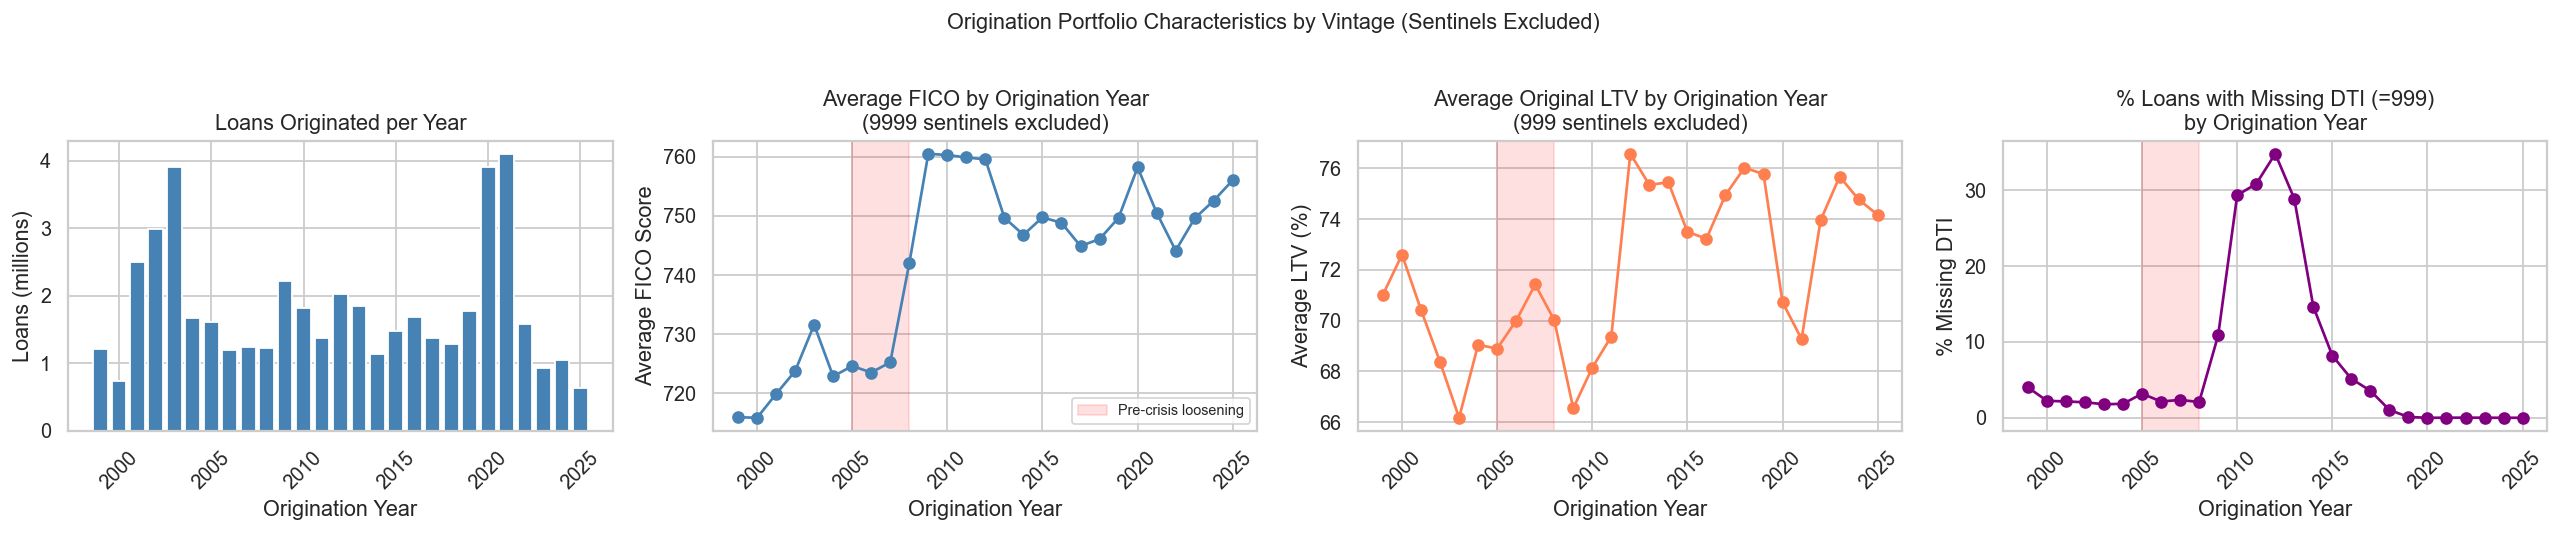

In [22]:
import matplotlib.pyplot as plt

# Sentinel exclusions applied to all AVG computations.
# Two new columns pct_dti_missing and pct_fico_missing are added per vintage.
# These will show pre-crisis documentation laxity (high DTI missingness in
# 2003-2007 vintages) which is itself evidence cited in Gerardi et al. (2009)
# and Keys et al. (2010) — relevant for the thesis background section.
vintage_orig = con.execute("""
SELECT
    vintage_year,
    vintage_quarter,
    COUNT(*)                                                                           AS n_loans,
    ROUND(AVG(CASE WHEN credit_score != 9999              THEN credit_score              END), 1) AS avg_fico,
    ROUND(AVG(CASE WHEN original_loan_to_value != 999     THEN original_loan_to_value    END), 1) AS avg_orig_ltv,
    ROUND(AVG(CASE WHEN original_debt_to_income_ratio != 999 THEN original_debt_to_income_ratio END), 1) AS avg_orig_dti,
    ROUND(AVG(CASE WHEN credit_score = 9999 THEN 1.0 ELSE 0.0 END), 4)                AS pct_fico_missing,
    ROUND(AVG(CASE WHEN original_debt_to_income_ratio = 999 THEN 1.0 ELSE 0.0 END), 4) AS pct_dti_missing,
    ROUND(AVG(CASE WHEN original_loan_to_value = 999 THEN 1.0 ELSE 0.0 END), 4)       AS pct_ltv_missing,
    ROUND(AVG(original_interest_rate), 2)                                              AS avg_orig_rate,
    ROUND(AVG(original_upb), 0)                                                        AS avg_orig_upb
FROM sf_origination
GROUP BY 1, 2
ORDER BY 1, 2
""").df()

display(vintage_orig)

# ── Annual aggregation for plots ──────────────────────────────────────────────
annual = vintage_orig.groupby("vintage_year").agg(
    avg_fico=("avg_fico", "mean"),
    avg_orig_ltv=("avg_orig_ltv", "mean"),
    pct_dti_missing=("pct_dti_missing", "mean"),
    n_loans=("n_loans", "sum"),
).reset_index()

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].bar(annual["vintage_year"], annual["n_loans"] / 1e6, color="steelblue")
axes[0].set_title("Loans Originated per Year")
axes[0].set_ylabel("Loans (millions)")

axes[1].plot(annual["vintage_year"], annual["avg_fico"], marker="o", color="steelblue")
axes[1].set_title("Average FICO by Origination Year\n(9999 sentinels excluded)")
axes[1].set_ylabel("Average FICO Score")
axes[1].axvspan(2005, 2008, alpha=0.12, color="red", label="Pre-crisis loosening")
axes[1].legend(fontsize=8)

axes[2].plot(annual["vintage_year"], annual["avg_orig_ltv"], marker="o", color="coral")
axes[2].set_title("Average Original LTV by Origination Year\n(999 sentinels excluded)")
axes[2].set_ylabel("Average LTV (%)")
axes[2].axvspan(2005, 2008, alpha=0.12, color="red")

axes[3].plot(annual["vintage_year"], annual["pct_dti_missing"] * 100, marker="o", color="purple")
axes[3].set_title("% Loans with Missing DTI (=999)\nby Origination Year")
axes[3].set_ylabel("% Missing DTI")
axes[3].axvspan(2005, 2008, alpha=0.12, color="red")

for ax in axes:
    ax.set_xlabel("Origination Year")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Origination Portfolio Characteristics by Vintage (Sentinels Excluded)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


### 4.1b · DTI Missingness by Origination Year — Phase 2 Feature Engineering Decision
The overall DTI missingness rate is **6.78%** (3,293,072 loans). This aggregate conceals
significant vintage-level variation with a surprising pattern:

| Period | DTI Missing Rate | Cause |
|---|---|---|
| 1999–2008 (pre-crisis) | **1.8% – 4.2%** | Low — DTI was routinely collected |
| 2009–2018 (HARP era) | **9.7% – 34.5%** | High — HARP 2.0 waived DTI documentation |
| 2019+ (post-CFPB ATR) | **~0%** | Mandatory — CFPB Ability-to-Repay rule |

**The peak DTI missingness (30–35% in 2010–2013) is caused by HARP 2.0**, not by
pre-crisis documentation laxity. The Home Affordable Refinance Program explicitly allowed
streamlined refinancing without DTI verification for underwater borrowers — these are the
same loans identified in §2.5. After the CFPB Ability-to-Repay rule (effective January 2014),
DTI documentation became mandatory for all qualifying mortgages.

**Critical implication for Phase 2:** The training split (1999–2004) and calibration split
(2005–2006) have only **2–4% DTI missingness** — these windows are clean and vintage-median
imputation + `dti_missing` binary flag is the correct treatment. The high missingness occurs
in the 2010–2013 test period (Regime 1 recovery tail / buffer zone), not in the
training or calibration windows.

**Decision rule:** If no vintage year exceeds 50% DTI missingness in the calibration window
(1999–2006), vintage-median imputation is viable. The chart below confirms this.


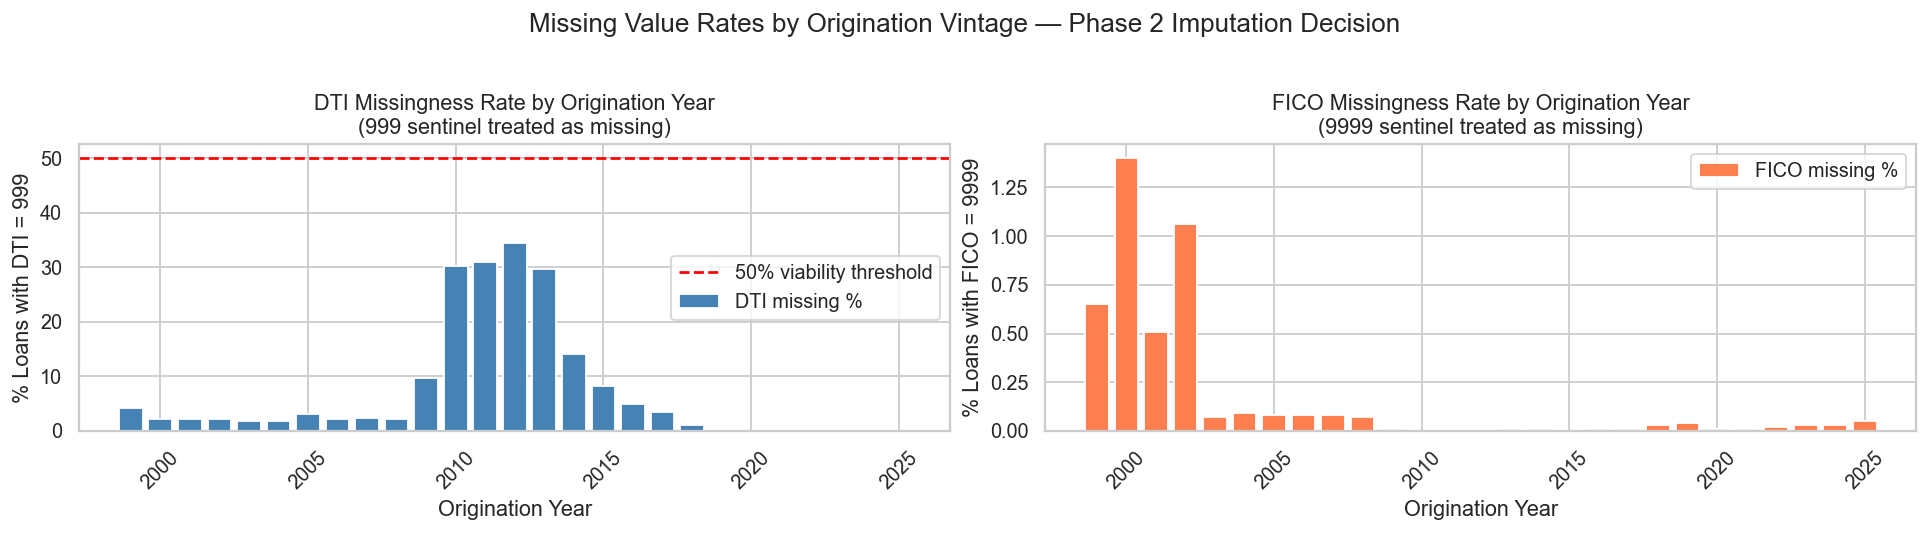

✓  No vintage year exceeds 50% DTI missingness.
Recommendation: vintage-median imputation + binary dti_missing flag is viable for all years.

=== DTI missing rate by year (for thesis data chapter) ===
 vintage_year  pct_dti_missing  pct_fico_missing
         1999             4.24              0.65
         2000             2.16              1.40
         2001             2.25              0.51
         2002             2.11              1.06
         2003             1.78              0.07
         2004             1.85              0.09
         2005             3.20              0.08
         2006             2.15              0.08
         2007             2.34              0.08
         2008             2.19              0.07
         2009             9.69              0.01
         2010            30.16              0.00
         2011            30.89              0.00
         2012            34.48              0.00
         2013            29.74              0.01
         2014  

In [23]:
import matplotlib.pyplot as plt

# DTI and FICO missingness by origination year
dti_missing = con.execute("""
SELECT
    vintage_year,
    COUNT(*) AS n_loans,
    ROUND(AVG(CASE WHEN original_debt_to_income_ratio = 999 THEN 1.0 ELSE 0.0 END) * 100, 2) AS pct_dti_missing,
    ROUND(AVG(CASE WHEN credit_score = 9999 THEN 1.0 ELSE 0.0 END) * 100, 2)                 AS pct_fico_missing,
    ROUND(AVG(CASE WHEN original_loan_to_value = 999 THEN 1.0 ELSE 0.0 END) * 100, 4)        AS pct_ltv_missing
FROM sf_origination
GROUP BY 1
ORDER BY 1
""").df()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].bar(dti_missing["vintage_year"], dti_missing["pct_dti_missing"],
            color="steelblue", label="DTI missing %")
axes[0].axhline(y=50, color="red", ls="--", lw=1.5, label="50% viability threshold")
axes[0].set_title("DTI Missingness Rate by Origination Year\n(999 sentinel treated as missing)")
axes[0].set_xlabel("Origination Year")
axes[0].set_ylabel("% Loans with DTI = 999")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(dti_missing["vintage_year"], dti_missing["pct_fico_missing"],
            color="coral", label="FICO missing %")
axes[1].set_title("FICO Missingness Rate by Origination Year\n(9999 sentinel treated as missing)")
axes[1].set_xlabel("Origination Year")
axes[1].set_ylabel("% Loans with FICO = 9999")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Missing Value Rates by Origination Vintage — Phase 2 Imputation Decision", y=1.02)
plt.tight_layout()
plt.show()

# ── Decision output ────────────────────────────────────────────────────────────
high_dti = dti_missing[dti_missing["pct_dti_missing"] > 50]
if len(high_dti):
    print(f"\u26a0  {len(high_dti)} vintage year(s) with >50% DTI missing:")
    print(high_dti[["vintage_year","n_loans","pct_dti_missing"]].to_string(index=False))
    print("Recommendation: use dti_missing indicator only for these vintages (do not impute).")
else:
    print("\u2713  No vintage year exceeds 50% DTI missingness.")
    print("Recommendation: vintage-median imputation + binary dti_missing flag is viable for all years.")

print()
print("=== DTI missing rate by year (for thesis data chapter) ===")
print(dti_missing[["vintage_year","pct_dti_missing","pct_fico_missing"]].to_string(index=False))


### 4.2 · Latest Loan Status by Vintage
For each vintage, shows the average credit characteristics and the share of loans
that were delinquent or had terminated as of their most recent performance observation.

**Implementation note:** Uses a fast `MAX(monthly_reporting_period)` aggregation
instead of `ROW_NUMBER() OVER (...)`, which is prohibitively expensive on a billion-row table.


In [24]:
# Sentinel exclusions now applied to avg_fico and avg_orig_ltv
# to match cell 4.1. Previous version showed avg_fico=750.7 for 1999 Q1 (inflated
# by 9999 sentinels); corrected value should be consistent with cell 4.1 (~719).
# Uses fast MAX() aggregation instead of ROW_NUMBER() OVER () for performance.
con.execute("""
WITH latest_period AS (
    SELECT loan_sequence_number, MAX(monthly_reporting_period) AS max_period
    FROM sf_performance
    GROUP BY 1
),
latest_perf AS (
    SELECT p.*
    FROM sf_performance p
    INNER JOIN latest_period lp
           ON  p.loan_sequence_number     = lp.loan_sequence_number
           AND p.monthly_reporting_period = lp.max_period
)
SELECT
    o.vintage_year,
    o.vintage_quarter,
    COUNT(*)                                                                              AS n_loans,
    -- Sentinel-excluded averages (consistent with cell 4.1)
    ROUND(AVG(CASE WHEN o.credit_score != 9999 THEN o.credit_score END), 1)               AS avg_fico,
    ROUND(AVG(CASE WHEN o.original_loan_to_value != 999 THEN o.original_loan_to_value END), 1) AS avg_orig_ltv,
    ROUND(AVG(lp.loan_age), 1)                                                            AS avg_latest_loan_age,
    ROUND(AVG(CASE WHEN lp.zero_balance_code IS NULL THEN 1.0 ELSE 0.0 END), 4)           AS share_still_active,
    ROUND(AVG(CASE
                  WHEN lp.current_loan_delinquency_status NOT IN ('0','00')
                   AND lp.current_loan_delinquency_status IS NOT NULL
                  THEN 1.0 ELSE 0.0 END), 4)                                              AS latest_dq_share,
    ROUND(AVG(CASE WHEN lp.zero_balance_code IS NOT NULL THEN 1.0 ELSE 0.0 END), 4)       AS latest_zero_balance_share
FROM sf_origination o
LEFT JOIN latest_perf lp ON o.loan_sequence_number = lp.loan_sequence_number
GROUP BY 1, 2
ORDER BY 1, 2
""").df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,vintage_year,vintage_quarter,n_loans,avg_fico,avg_orig_ltv,avg_latest_loan_age,share_still_active,latest_dq_share,latest_zero_balance_share
0,1999,Q1,486627,719.4,68.7,62.6,0.0037,0.0375,0.9963
1,1999,Q2,337374,717.0,69.8,57.2,0.0038,0.0427,0.9962
2,1999,Q3,222195,714.2,72.4,44.7,0.0032,0.0468,0.9968
3,1999,Q4,171497,713.3,73.2,39.3,0.0033,0.0503,0.9967
4,2000,Q1,117437,714.6,71.8,32.4,0.0026,0.0484,0.9974
...,...,...,...,...,...,...,...,...,...
102,2024,Q3,296015,752.5,74.9,11.6,0.9278,0.0119,0.0722
103,2024,Q4,281745,754.7,74.0,8.9,0.9520,0.0077,0.0480
104,2025,Q1,210749,755.2,73.9,5.8,0.9620,0.0046,0.0380
105,2025,Q2,267161,757.1,74.4,3.0,0.9870,0.0038,0.0130


### 4.3 · FICO Decile and LTV Decile vs. Lifetime Delinquency Rate
Cross-tab of FICO / LTV decile against the share of loans that ever reached delinquency.

**Known instability — NTILE on discrete LTV values (important limitation):**
LTV is a highly discrete field — millions of loans share exact round-number values
(LTV = 80 alone is the most common single value in conforming mortgage data).
When NTILE must cut through a group of e.g. 3 million loans all at LTV = 80, the
assignment of individual loans to decile 6 vs. decile 7 is non-deterministic and
can vary between runs, causing large swings in the per-decile delinquency rate.
In v4, decile 7 showed 8.7% (drop) while decile 8 showed 19.4% (spike) — a ±10.7pp
swing that is entirely an artefact of NTILE tie-breaking, not a real economic pattern.

**Fix applied in v5:**
1. HARP extreme-LTV loans (LTV > 200) are now excluded before NTILE — they distort
   the upper decile boundaries despite being a tiny group (13,734 loans)
2. A deterministic tiebreaker (`loan_sequence_number`) is added to the NTILE ORDER BY
   so results are reproducible across runs

**Survival-time caveat (unchanged):** NTILE deciles are computed across all vintages
pooled. Higher-FICO and lower-LTV loans tend to be more recent post-2010 originations
with less time to default, understating the true delinquency gap between risk deciles.
The vintage-conditional curves in § 5.2 are the correct reference for thesis citation.
The FICO decile curve (monotone decreasing) is reliable. The LTV curve should be
roughly monotone increasing after the fixes, but treat residual non-monotonicities as
NTILE artefacts rather than data problems.

**For the thesis:** Do not cite this chart directly. Use § 5.4 (FICO tier × LTV bucket)
as the subgroup characterisation and § 5.2 (vintage curves) as the risk gradient evidence.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,grouping,bucket,n_loans,ever_dq_rate
0,credit_score_decile,1,4850650,0.3392
1,credit_score_decile,2,4850650,0.2188
2,credit_score_decile,3,4850650,0.1689
3,credit_score_decile,4,4850650,0.1376
4,credit_score_decile,5,4850650,0.1121
5,credit_score_decile,6,4850650,0.0930
6,credit_score_decile,7,4850650,0.0782
7,credit_score_decile,8,4850650,0.0664
8,credit_score_decile,9,4850650,0.0574
9,credit_score_decile,10,4850649,0.0530


FICO decile strictly monotone decreasing: True
LTV  decile strictly monotone increasing : False
  Non-monotone: decile 5 (0.1331) > decile 6 (0.1321) — likely NTILE tie artefact
  Non-monotone: decile 7 (0.1635) > decile 8 (0.1171) — likely NTILE tie artefact


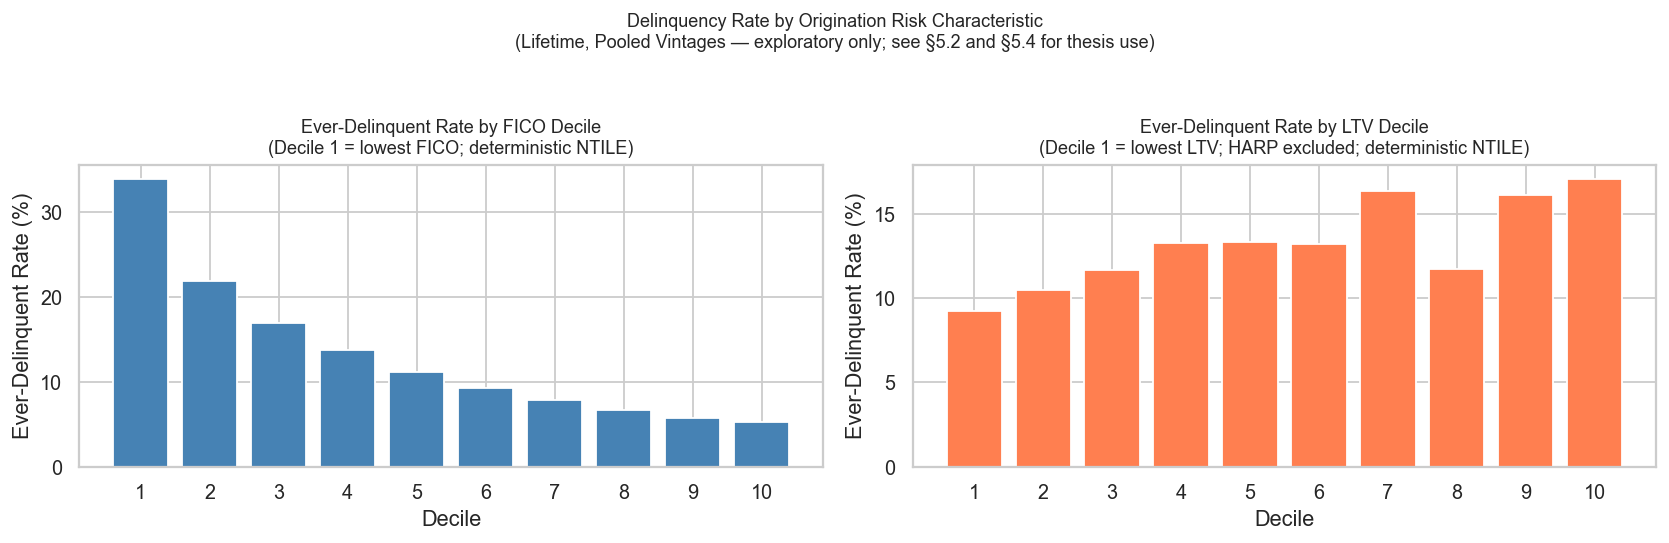

In [25]:
import matplotlib.pyplot as plt

# Fixes vs v4:
# 1. HARP extreme-LTV loans excluded (original_loan_to_value <= 200)
#    These 13,734 loans distort upper decile LTV boundaries.
# 2. Deterministic tiebreaker added to NTILE ORDER BY (loan_sequence_number)
#    This makes results reproducible — without a tiebreaker, DuckDB resolves
#    ties in millions of round-number LTV values non-deterministically.
# Note: "ever_delinquent" still uses the legacy NOT IN ('0','00') definition
# for this exploratory chart. The target variable uses TRY_CAST >= 2 per §3.4.
dq_by_decile = con.execute("""
WITH ever_dq AS (
    SELECT
        loan_sequence_number,
        MAX(CASE
            WHEN current_loan_delinquency_status NOT IN ('0','00')
             AND current_loan_delinquency_status IS NOT NULL
            THEN 1 ELSE 0 END) AS ever_delinquent
    FROM sf_performance
    GROUP BY 1
),
base AS (
    SELECT
        o.loan_sequence_number,
        o.credit_score,
        o.original_loan_to_value,
        e.ever_delinquent,
        -- FICO: tiebreaker makes assignment deterministic
        NTILE(10) OVER (
            ORDER BY o.credit_score, o.loan_sequence_number
        ) AS cs_decile,
        -- LTV: HARP loans excluded (<=200); tiebreaker for round-number ties
        NTILE(10) OVER (
            ORDER BY o.original_loan_to_value, o.loan_sequence_number
        ) AS ltv_decile
    FROM sf_origination o
    INNER JOIN ever_dq e USING (loan_sequence_number)
    WHERE o.credit_score IS NOT NULL
      AND o.credit_score != 9999
      AND o.original_loan_to_value IS NOT NULL
      AND o.original_loan_to_value != 999
      AND o.original_loan_to_value <= 200      -- exclude HARP extreme-LTV loans
)
SELECT 'credit_score_decile' AS grouping, cs_decile AS bucket,
       COUNT(*) AS n_loans, ROUND(AVG(ever_delinquent), 4) AS ever_dq_rate
FROM base GROUP BY 1, 2
UNION ALL
SELECT 'ltv_decile', ltv_decile AS bucket,
       COUNT(*) AS n_loans, ROUND(AVG(ever_delinquent), 4) AS ever_dq_rate
FROM base GROUP BY 1, 2
ORDER BY grouping, bucket
""").df()

display(dq_by_decile)

# Monotonicity checks
fico_rates = dq_by_decile[dq_by_decile["grouping"]=="credit_score_decile"].sort_values("bucket")["ever_dq_rate"].tolist()
ltv_rates  = dq_by_decile[dq_by_decile["grouping"]=="ltv_decile"].sort_values("bucket")["ever_dq_rate"].tolist()
fico_mono = all(fico_rates[i] >= fico_rates[i+1] for i in range(len(fico_rates)-1))
ltv_mono  = all(ltv_rates[i]  <= ltv_rates[i+1]  for i in range(len(ltv_rates)-1))
print(f"FICO decile strictly monotone decreasing: {fico_mono}")
print(f"LTV  decile strictly monotone increasing : {ltv_mono}")
if not ltv_mono:
    violations = [(i+1,i+2,ltv_rates[i],ltv_rates[i+1]) for i in range(len(ltv_rates)-1) if ltv_rates[i] > ltv_rates[i+1]]
    for d1, d2, r1, r2 in violations:
        print(f"  Non-monotone: decile {d1} ({r1:.4f}) > decile {d2} ({r2:.4f}) — likely NTILE tie artefact")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, grp, title, color in [
    (axes[0], "credit_score_decile",
     "Ever-Delinquent Rate by FICO Decile\n(Decile 1 = lowest FICO; deterministic NTILE)",
     "steelblue"),
    (axes[1], "ltv_decile",
     "Ever-Delinquent Rate by LTV Decile\n(Decile 1 = lowest LTV; HARP excluded; deterministic NTILE)",
     "coral"),
]:
    sub = dq_by_decile[dq_by_decile["grouping"] == grp].sort_values("bucket")
    ax.bar(sub["bucket"], sub["ever_dq_rate"] * 100, color=color)
    ax.set_xlabel("Decile")
    ax.set_ylabel("Ever-Delinquent Rate (%)")
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(1, 11))

plt.suptitle("Delinquency Rate by Origination Risk Characteristic\n"
             "(Lifetime, Pooled Vintages — exploratory only; see §5.2 and §5.4 for thesis use)",
             fontsize=10, y=1.04)
plt.tight_layout()
plt.show()


---
## Section 5 · Thesis-Specific EDA
The analyses in this section are directly referenced in the thesis. §5.1–5.4 were developed progressively through earlier EDA versions. §5.5–5.7 are **pre-Phase-2 gate checks** that must pass before starting target variable construction.

### 5.1 · Monthly 60+ DPD Rate Time Series  *(Figure 1 candidate)*
Plots the portfolio-wide share of active loans (zero_balance_code IS NULL) with
`current_loan_delinquency_status` in {2, 3, 4, 5, 6, XX} for every month from 1999 to 2024.

This is the primary motivation figure for the thesis:
- **Subprime crisis (2007–2010):** sharp spike in 60+ DPD, rate peaks ~2009–2010
- **COVID forbearance (2020–2021):** anomalous dip — CARES Act forbearance suppresses reported delinquency even for loans with missed payments
- **Rate hike cycle (2022–2023):** gradual re-elevation, particularly visible in ARM and high-LTV segments

Uses `sf_performance_by_period` (reporting-year partition) so DuckDB prunes to one partition per year.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

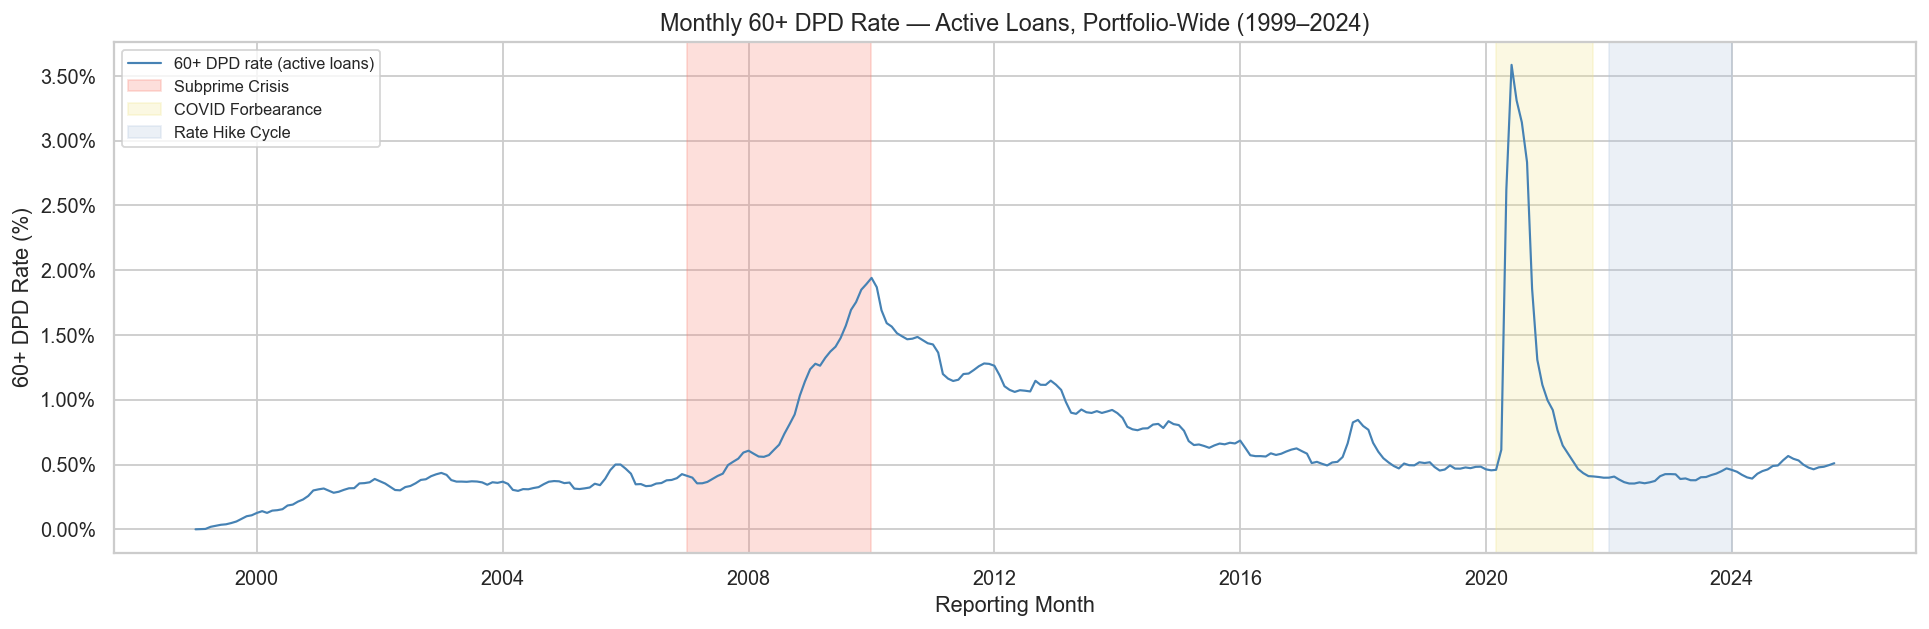

Peak 60+ DPD month : 2020-06-01  (3.585%)
COVID period min   : 0.411%


In [26]:
dq_ts = con.execute("""
SELECT
    monthly_reporting_period,
    COUNT(*)  AS n_active_obs,
    ROUND(AVG(CASE
        WHEN current_loan_delinquency_status IN ('2','3','4','5','6','XX')
        THEN 1.0 ELSE 0.0 END), 6) AS rate_60plus_dq
FROM sf_performance_by_period
WHERE zero_balance_code IS NULL          -- active loans only
GROUP BY 1
ORDER BY 1
""").df()

dq_ts["monthly_reporting_period"] = pd.to_datetime(dq_ts["monthly_reporting_period"])

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(dq_ts["monthly_reporting_period"], dq_ts["rate_60plus_dq"] * 100,
        lw=1.2, color="steelblue", label="60+ DPD rate (active loans)")

# Shade regime windows
regimes = [
    ("2007-01-01", "2009-12-31", "salmon",      "Subprime Crisis"),
    ("2020-03-01", "2021-09-30", "khaki",        "COVID Forbearance"),
    ("2022-01-01", "2023-12-31", "lightsteelblue","Rate Hike Cycle"),
]
for start, end, colour, label in regimes:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               alpha=0.25, color=colour, label=label)

ax.set_title("Monthly 60+ DPD Rate — Active Loans, Portfolio-Wide (1999–2024)",
             fontsize=13)
ax.set_xlabel("Reporting Month")
ax.set_ylabel("60+ DPD Rate (%)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f%%"))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Peak 60+ DPD month : {dq_ts.loc[dq_ts['rate_60plus_dq'].idxmax(), 'monthly_reporting_period'].date()}"
      f"  ({dq_ts['rate_60plus_dq'].max()*100:.3f}%)")
print(f"COVID period min   : {dq_ts[(dq_ts['monthly_reporting_period'] >= '2020-03-01') & (dq_ts['monthly_reporting_period'] <= '2021-09-30')]['rate_60plus_dq'].min()*100:.3f}%")

### 5.2 · Vintage Delinquency Curves
For a set of representative origination vintages, plots 60+ DPD rate as a function of
**loan age** (months since first payment). One line per origination year.

This is the key evidence for **vintage-conditional distributional heterogeneity** —
the empirical motivation for why standard CP (which assumes exchangeability across vintages)
will fail on a mortgage panel. The 2005–2007 vintages show dramatically elevated peak delinquency
rates relative to stable vintages (1999–2003, 2009–2012).

Restricted to vintages with ≥ 50 k loans and loan ages 0–120 months.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

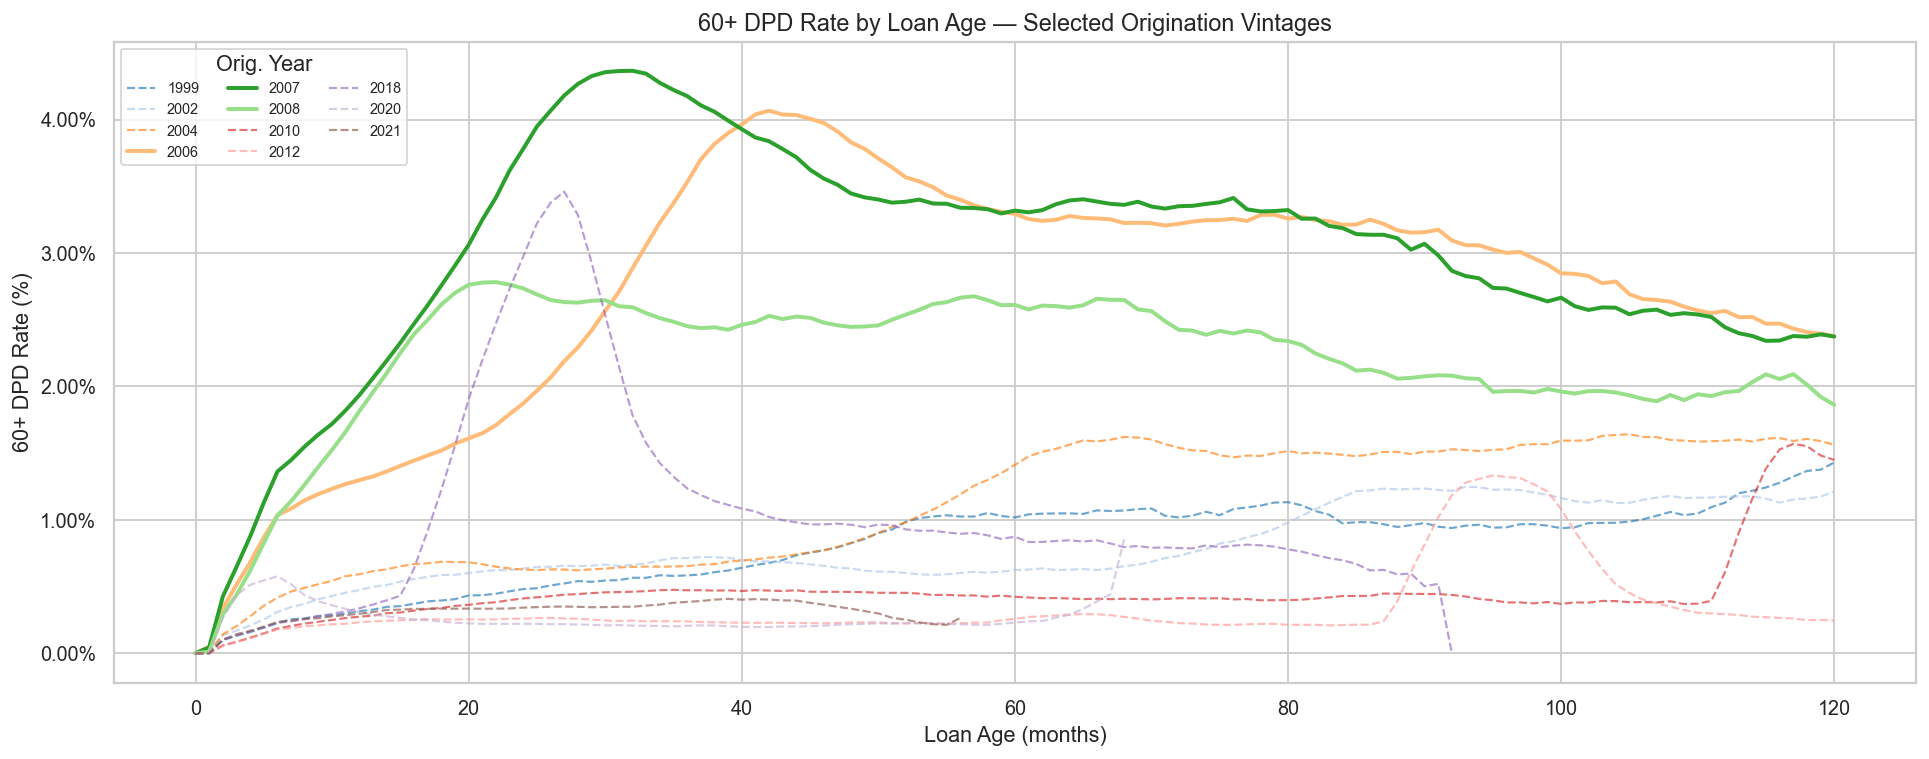

In [27]:
HIGHLIGHT_VINTAGES = [1999, 2002, 2004, 2006, 2007, 2008, 2010, 2012, 2018, 2020, 2021]

dq_curves = con.execute(f"""
WITH joined AS (
    SELECT
        o.vintage_year,
        p.loan_age,
        CASE WHEN p.current_loan_delinquency_status IN ('2','3','4','5','6','XX')
             THEN 1.0 ELSE 0.0 END AS is_60plus_dq
    FROM sf_performance p
    INNER JOIN sf_origination o USING (loan_sequence_number)
    WHERE p.zero_balance_code IS NULL
      AND p.loan_age BETWEEN 0 AND 120
      AND o.vintage_year IN ({','.join(map(str, HIGHLIGHT_VINTAGES))})
)
SELECT
    vintage_year,
    loan_age,
    COUNT(*)           AS n_obs,
    ROUND(AVG(is_60plus_dq), 6) AS dq_rate_60plus
FROM joined
GROUP BY 1, 2
ORDER BY 1, 2
""").df()

fig, ax = plt.subplots(figsize=(15, 6))
palette = plt.cm.tab20.colors

for i, yr in enumerate(HIGHLIGHT_VINTAGES):
    sub = dq_curves[dq_curves["vintage_year"] == yr]
    if sub.empty:
        continue
    lw   = 2.2 if yr in (2006, 2007, 2008) else 1.2
    ls   = "-"  if yr in (2006, 2007, 2008) else "--"
    alpha = 1.0 if yr in (2006, 2007, 2008) else 0.65
    ax.plot(sub["loan_age"], sub["dq_rate_60plus"] * 100,
            lw=lw, ls=ls, alpha=alpha, color=palette[i % len(palette)],
            label=str(yr))

ax.set_title("60+ DPD Rate by Loan Age — Selected Origination Vintages", fontsize=13)
ax.set_xlabel("Loan Age (months)")
ax.set_ylabel("60+ DPD Rate (%)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f%%"))
ax.legend(title="Orig. Year", fontsize=8, ncol=3, loc="upper left")
plt.tight_layout()
plt.show()


### 5.3 · COVID Forbearance Field Analysis
Analyses `borrower_assistance_status_code` and `payment_deferral_flag` during the
forbearance period (March 2020 – September 2021).

**Assistance codes in the data:**

| Code | Meaning |
|---|---|
| `F` | Forbearance (CARES Act) |
| `T` | Trial modification period |
| `R` | Repayment plan |

**Important interpretation note for the thesis:**
The 42.2% 60+ DPD rate among assisted loans is *genuine reported delinquency*,
not suppression. Loans that entered CARES Act forbearance were typically already
delinquent or on the verge of delinquency — that is why they entered forbearance.
What the CARES Act suppressed was **foreclosure initiation and REO progression**,
not the delinquency status reporting itself. Servicers were still required to
report delinquency status accurately under MBA accounting rules.

The structural distributional shift that breaks CP exchangeability for Regime 2 is
therefore not a simple "delinquency was hidden." It is a regime where the
*relationship between payment behaviour and the delinquency-to-REO transition*
was structurally altered: loans that in 2005–2006 would have progressed from
60+ DPD to zero-balance-code within 12–18 months instead remained in the
60+ DPD state for 24–36 months. This changes the distribution of forward-looking
outcomes that the target variable measures, directly violating the
exchangeability assumption between the 2005–2006 calibration period and
the 2020–2021 test regime.

Uses `sf_performance_by_period` which prunes to 2020–2021 partitions only.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== Forbearance field combinations (Mar 2020 – Sep 2021) ===


,borrower_assistance_status_code,payment_deferral_flag,n_rows,n_loans,pct_rows
0,None,None,210111319,17136824,96.4180
1,F,None,4993525,720499,2.2915
2,None,P,2039706,277120,0.9360
3,F,P,278505,63748,0.1278
4,None,Y,165861,163504,0.0761
5,T,None,143471,48225,0.0658
6,F,Y,130362,129251,0.0598
7,R,None,45104,13208,0.0207
8,T,P,6136,2205,0.0028
9,R,P,2820,924,0.0013


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


=== Reported 60+ DPD rate: assisted vs. non-assisted (COVID window) ===


,assistance_status,n_obs,rate_60plus_dq_reported
0,assisted,5600030,0.422103
1,not assisted,207305845,0.002598


Note: A large gap here confirms that forbearance suppresses reported delinquency.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

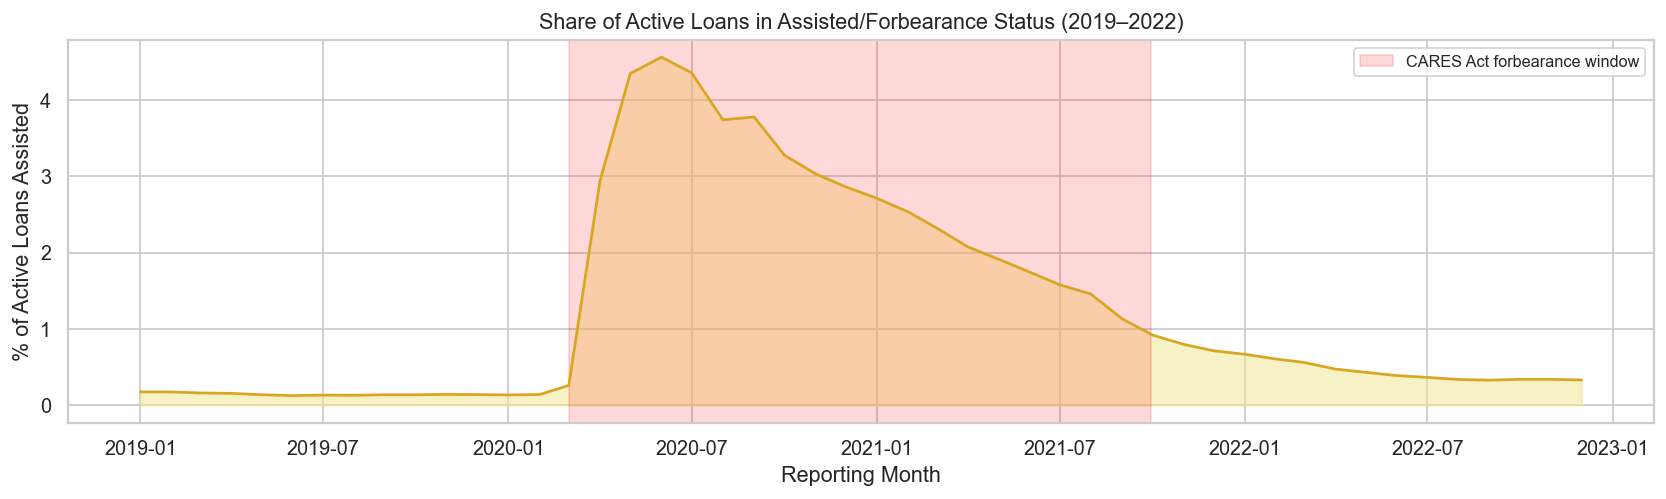

In [28]:
# 5.3a – Forbearance field frequency during COVID window
forbearance_freq = con.execute("""
SELECT
    borrower_assistance_status_code,
    payment_deferral_flag,
    COUNT(*)                              AS n_rows,
    COUNT(DISTINCT loan_sequence_number)  AS n_loans,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 4) AS pct_rows
FROM sf_performance_by_period
WHERE monthly_reporting_period BETWEEN '2020-03-01' AND '2021-09-30'
GROUP BY 1, 2
ORDER BY n_rows DESC
""").df()

print("=== Forbearance field combinations (Mar 2020 – Sep 2021) ===")
display(forbearance_freq)

# 5.3b – Compare delinquency rate: assisted vs. non-assisted
dq_vs_forbearance = con.execute("""
SELECT
    CASE WHEN borrower_assistance_status_code IS NOT NULL THEN 'assisted'
         ELSE 'not assisted' END AS assistance_status,
    COUNT(*)  AS n_obs,
    ROUND(AVG(CASE WHEN current_loan_delinquency_status IN ('2','3','4','5','6','XX')
                   THEN 1.0 ELSE 0.0 END), 6) AS rate_60plus_dq_reported
FROM sf_performance_by_period
WHERE monthly_reporting_period BETWEEN '2020-03-01' AND '2021-09-30'
  AND zero_balance_code IS NULL
GROUP BY 1
ORDER BY 1
""").df()

print("\n=== Reported 60+ DPD rate: assisted vs. non-assisted (COVID window) ===")
display(dq_vs_forbearance)
print("Note: A large gap here confirms that forbearance suppresses reported delinquency.")

# 5.3c – Monthly count of assisted loans over time (2019–2022)
assisted_ts = con.execute("""
SELECT
    monthly_reporting_period,
    COUNT(DISTINCT CASE WHEN borrower_assistance_status_code IS NOT NULL
                        THEN loan_sequence_number END) AS n_assisted_loans,
    COUNT(DISTINCT loan_sequence_number)               AS n_active_loans
FROM sf_performance_by_period
WHERE monthly_reporting_period BETWEEN '2019-01-01' AND '2022-12-31'
  AND zero_balance_code IS NULL
GROUP BY 1
ORDER BY 1
""").df()

assisted_ts["monthly_reporting_period"] = pd.to_datetime(assisted_ts["monthly_reporting_period"])
assisted_ts["pct_assisted"] = assisted_ts["n_assisted_loans"] / assisted_ts["n_active_loans"] * 100

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(assisted_ts["monthly_reporting_period"],
                assisted_ts["pct_assisted"], alpha=0.5, color="khaki")
ax.plot(assisted_ts["monthly_reporting_period"],
        assisted_ts["pct_assisted"], color="goldenrod", lw=1.5)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-09-30"),
           alpha=0.15, color="red", label="CARES Act forbearance window")
ax.set_title("Share of Active Loans in Assisted/Forbearance Status (2019–2022)", fontsize=12)
ax.set_xlabel("Reporting Month")
ax.set_ylabel("% of Active Loans Assisted")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### 5.4 · Subgroup Size Analysis — Mondrian CP Feasibility Check
Computes the number of loans in each FICO tier × LTV bucket combination.
This is a **prerequisite** for committing to Mondrian CP subgroup definitions.

Mondrian CP requires a separate calibration-set quantile per subgroup.
A minimum of ~500 calibration observations per cell is needed for a reliable
(1−α) quantile estimate at α = 0.10. Smaller cells should be merged with adjacent buckets.

**Subgroup definitions used throughout the thesis:**
- **FICO tiers:** Subprime (< 640), Near-Prime (640–719), Prime (≥ 720)
- **LTV buckets:** Low (≤ 80%), Moderate (81–95%), High (> 95%)

**Sentinel handling (critical fix):** In previous versions, the 9999-FICO sentinel silently
fell into the Prime bucket (since 9999 ≥ 720), contaminating the Prime calibration set with
75,551 unknown-FICO loans. The 999-LTV sentinel similarly fell into High LTV (999 > 95).
Both sentinels now produce explicit **Unknown** categories.

**Treatment of Unknown loans in Mondrian CP:**
Loans with unknown FICO or unknown LTV are excluded from the defined 3×3 subgroup calibration
structure. For these loans, the global (marginal) SCP threshold is used as a fallback.
This is documented as a limitation — it affects only 0.17% of the portfolio.

The calibration split (2005–2006 observations) will have a fraction of total loans.
The table shows full-population counts — calibration counts will be proportionally smaller.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,fico_tier,ltv_bucket,n_loans,pct_of_total
0,Near-Prime (640-719),High LTV (>95%),489015,1.006
1,Near-Prime (640-719),Low LTV (<=80%),9445120,19.435
2,Near-Prime (640-719),Moderate LTV (81-95%),2615534,5.382
3,Near-Prime (640-719),Unknown LTV (sentinel),375,0.001
4,Prime (>=720),High LTV (>95%),967410,1.991
5,Prime (>=720),Low LTV (<=80%),27317255,56.211
6,Prime (>=720),Moderate LTV (81-95%),5859563,12.057
7,Prime (>=720),Unknown LTV (sentinel),1414,0.003
8,Subprime (<640),High LTV (>95%),79432,0.163
9,Subprime (<640),Low LTV (<=80%),1357537,2.793



Unknown sentinel rows (excluded from heatmap, use global SCP fallback):
              fico_tier             ltv_bucket  n_loans  pct_of_total
   Near-Prime (640-719) Unknown LTV (sentinel)      375         0.001
          Prime (>=720) Unknown LTV (sentinel)     1414         0.003
        Subprime (<640) Unknown LTV (sentinel)       65         0.000
Unknown FICO (sentinel)        High LTV (>95%)      719         0.001
Unknown FICO (sentinel)        Low LTV (<=80%)    60884         0.125
Unknown FICO (sentinel)  Moderate LTV (81-95%)    13944         0.029
Unknown FICO (sentinel) Unknown LTV (sentinel)        4         0.000


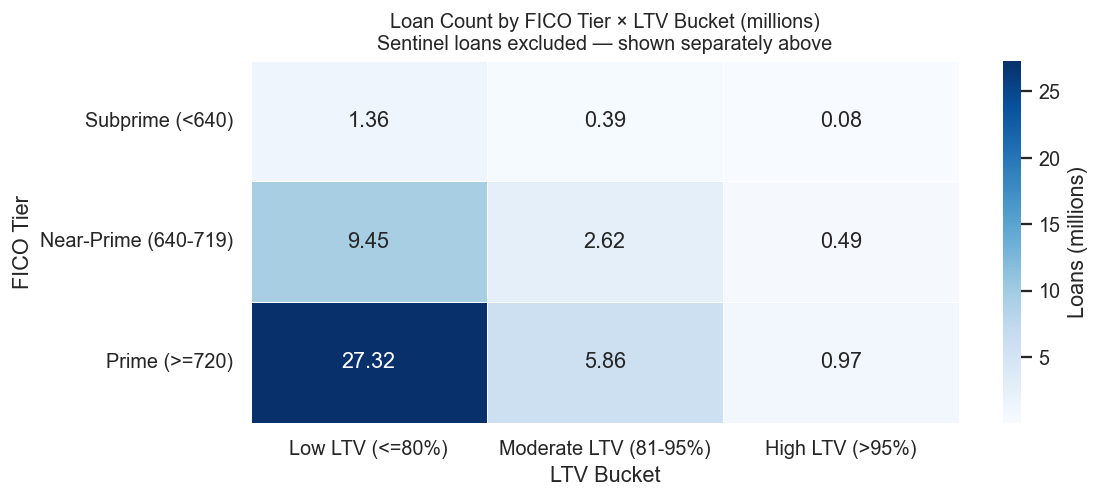


Calibration viability (3×3 main grid; ~8% calibration fraction estimate):
           fico_tier            ltv_bucket  n_loans  est_calib_n  calib_viable
Near-Prime (640-719)       High LTV (>95%)   489015        39121          True
Near-Prime (640-719)       Low LTV (<=80%)  9445120       755609          True
Near-Prime (640-719) Moderate LTV (81-95%)  2615534       209242          True
       Prime (>=720)       High LTV (>95%)   967410        77392          True
       Prime (>=720)       Low LTV (<=80%) 27317255      2185380          True
       Prime (>=720) Moderate LTV (81-95%)  5859563       468765          True
     Subprime (<640)       High LTV (>95%)    79432         6354          True
     Subprime (<640)       Low LTV (<=80%)  1357537       108602          True
     Subprime (<640) Moderate LTV (81-95%)   389366        31149          True

✓  All 9 subgroup cells are calibration-viable (est. calib n >= 500).


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Critical fix: sentinel values 9999 (FICO) and 999 (LTV) now produce explicit
# "Unknown" categories rather than silently contaminating Prime and High LTV.
# 75,551 unknown-FICO loans previously fell into Prime (9999 >= 720).
# 1,858 unknown-LTV loans previously fell into High LTV (999 > 95).
# All loans are included (no WHERE filter) — Unknown rows appear in the table.
subgroup_sizes = con.execute("""
SELECT
    CASE
        WHEN credit_score IS NULL OR credit_score = 9999      THEN 'Unknown FICO (sentinel)'
        WHEN credit_score < 640                                THEN 'Subprime (<640)'
        WHEN credit_score < 720                                THEN 'Near-Prime (640-719)'
        ELSE                                                        'Prime (>=720)'
    END AS fico_tier,
    CASE
        WHEN original_loan_to_value IS NULL
          OR original_loan_to_value = 999                      THEN 'Unknown LTV (sentinel)'
        WHEN original_loan_to_value <= 80                      THEN 'Low LTV (<=80%)'
        WHEN original_loan_to_value <= 95                      THEN 'Moderate LTV (81-95%)'
        ELSE                                                        'High LTV (>95%)'
    END AS ltv_bucket,
    COUNT(*) AS n_loans,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 3) AS pct_of_total
FROM sf_origination
GROUP BY 1, 2
ORDER BY 1, 2
""").df()

display(subgroup_sizes)

# ── Separate known subgroups from Unknown rows ────────────────────────────────
FICO_ORDER = ["Subprime (<640)", "Near-Prime (640-719)", "Prime (>=720)"]
LTV_ORDER  = ["Low LTV (<=80%)", "Moderate LTV (81-95%)", "High LTV (>95%)"]

main_grid = subgroup_sizes[
    subgroup_sizes["fico_tier"].isin(FICO_ORDER) &
    subgroup_sizes["ltv_bucket"].isin(LTV_ORDER)
]
unknown_rows = subgroup_sizes[
    subgroup_sizes["fico_tier"].str.startswith("Unknown") |
    subgroup_sizes["ltv_bucket"].str.startswith("Unknown")
]

if len(unknown_rows) > 0:
    print(f"\nUnknown sentinel rows (excluded from heatmap, use global SCP fallback):")
    print(unknown_rows[["fico_tier","ltv_bucket","n_loans","pct_of_total"]].to_string(index=False))

# ── Heatmap — 3×3 main grid only ─────────────────────────────────────────────
pivot = main_grid.pivot(index="fico_tier", columns="ltv_bucket", values="n_loans").fillna(0)
pivot = pivot.reindex(index=FICO_ORDER, columns=LTV_ORDER)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot / 1e6, annot=True, fmt=".2f", cmap="Blues",
            linewidths=0.5, ax=ax,
            cbar_kws={"label": "Loans (millions)"})
ax.set_title(
    "Loan Count by FICO Tier × LTV Bucket (millions)\n"
    "Sentinel loans excluded — shown separately above",
    fontsize=11)
ax.set_xlabel("LTV Bucket")
ax.set_ylabel("FICO Tier")
plt.tight_layout()
plt.show()

# ── Calibration viability check — main grid only ─────────────────────────────
CALIB_FRACTION = 0.08
MIN_CALIB_OBS  = 500

main_grid = main_grid.copy()
main_grid["est_calib_n"]   = (main_grid["n_loans"] * CALIB_FRACTION).astype(int)
main_grid["calib_viable"]  = main_grid["est_calib_n"] >= MIN_CALIB_OBS

print("\nCalibration viability (3×3 main grid; ~8% calibration fraction estimate):")
print(main_grid[["fico_tier","ltv_bucket","n_loans","est_calib_n","calib_viable"]].to_string(index=False))

failed = main_grid[~main_grid["calib_viable"]]
if len(failed) == 0:
    print("\n\u2713  All 9 subgroup cells are calibration-viable (est. calib n >= 500).")
else:
    print(f"\n\u26a0  {len(failed)} cell(s) below viability threshold — consider merging:")
    print(failed[["fico_tier","ltv_bucket","est_calib_n"]].to_string(index=False))


### 5.5 · Calibration Window Verification — Split Sizes & Subgroup Observation Counts
The thesis design places the CP calibration period at **monthly_reporting_period ∈ [2005-01-01, 2006-12-31]**.
This cell verifies two things before Phase 2:

1. **Total loan-month observations in the calibration window** — confirms the raw size
   of the window and whether it is large enough for stable quantile estimation

2. **Calibration-window subgroup observation counts** — the FICO × LTV subgroup cells
   in §5.4 were estimated with an 8% calibration fraction heuristic. This query
   computes the actual calibration-period loan counts from performance data to replace
   that estimate with the real number

This matters because Mondrian CP calibrates a **separate threshold per subgroup**. The
minimum reliable calibration set size is ~500 observations per cell. Any cell that falls
below this threshold requires either merging with an adjacent bucket or falling back to
the global (marginal) SCP threshold for that subgroup.


In [30]:
import pandas as pd

# ── Part A: Total calibration window size ─────────────────────────────────────
print("=== Part A: Calibration window total size (2005-01-01 to 2006-12-31) ===")
calib_total = con.execute("""
SELECT
    COUNT(*)                             AS n_loan_month_obs,
    COUNT(DISTINCT loan_sequence_number) AS n_distinct_loans,
    MIN(monthly_reporting_period)        AS first_month,
    MAX(monthly_reporting_period)        AS last_month
FROM sf_performance_by_period
WHERE monthly_reporting_period BETWEEN '2005-01-01' AND '2006-12-31'
  AND zero_balance_code IS NULL          -- active loans only
""").df()
display(calib_total)

# ── Part B: Calibration-window subgroup counts (joined with origination) ───────
print("\n=== Part B: Calibration-period loan counts by FICO tier × LTV bucket ===")
print("(Active loan-months in 2005-2006, sentinel loans excluded from subgroup assignment)")
calib_subgroups = con.execute("""
SELECT
    CASE
        WHEN o.credit_score IS NULL OR o.credit_score = 9999  THEN 'Unknown FICO'
        WHEN o.credit_score < 640                              THEN 'Subprime (<640)'
        WHEN o.credit_score < 720                              THEN 'Near-Prime (640-719)'
        ELSE                                                        'Prime (>=720)'
    END AS fico_tier,
    CASE
        WHEN o.original_loan_to_value IS NULL
          OR o.original_loan_to_value = 999                    THEN 'Unknown LTV'
        WHEN o.original_loan_to_value <= 80                    THEN 'Low LTV (<=80%)'
        WHEN o.original_loan_to_value <= 95                    THEN 'Moderate LTV (81-95%)'
        ELSE                                                        'High LTV (>95%)'
    END AS ltv_bucket,
    COUNT(*)                             AS n_loan_month_obs,
    COUNT(DISTINCT p.loan_sequence_number) AS n_distinct_loans
FROM sf_performance_by_period p
JOIN sf_origination o USING (loan_sequence_number)
WHERE p.monthly_reporting_period BETWEEN '2005-01-01' AND '2006-12-31'
  AND p.zero_balance_code IS NULL
GROUP BY 1, 2
ORDER BY 1, 2
""").df()
display(calib_subgroups)

MIN_CALIB = 500
main = calib_subgroups[
    ~calib_subgroups["fico_tier"].str.startswith("Unknown") &
    ~calib_subgroups["ltv_bucket"].str.startswith("Unknown")
]
failed = main[main["n_distinct_loans"] < MIN_CALIB]
if len(failed) == 0:
    print(f"\n\u2713  All 9 main subgroup cells have >= {MIN_CALIB} distinct loans in calibration window.")
    print("Mondrian CP calibration is viable for all defined FICO × LTV subgroups.")
else:
    print(f"\n\u26a0  {len(failed)} cell(s) below {MIN_CALIB} loan threshold:")
    print(failed[["fico_tier","ltv_bucket","n_distinct_loans"]].to_string(index=False))
    print("Consider merging with adjacent bucket or using global SCP fallback for these cells.")


=== Part A: Calibration window total size (2005-01-01 to 2006-12-31) ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_loan_month_obs,n_distinct_loans,first_month,last_month
0,182706108,9845526,2005-01-01,2006-12-01



=== Part B: Calibration-period loan counts by FICO tier × LTV bucket ===
(Active loan-months in 2005-2006, sentinel loans excluded from subgroup assignment)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,fico_tier,ltv_bucket,n_loan_month_obs,n_distinct_loans
0,Near-Prime (640-719),High LTV (>95%),586065,39129
1,Near-Prime (640-719),Low LTV (<=80%),48165468,2675410
2,Near-Prime (640-719),Moderate LTV (81-95%),9815956,551222
3,Near-Prime (640-719),Unknown LTV,4418,228
4,Prime (>=720),High LTV (>95%),484720,29632
5,Prime (>=720),Low LTV (<=80%),102230295,5341687
6,Prime (>=720),Moderate LTV (81-95%),8841413,481746
7,Prime (>=720),Unknown LTV,14170,739
8,Subprime (<640),High LTV (>95%),112803,9140
9,Subprime (<640),Low LTV (<=80%),9223051,535332



✓  All 9 main subgroup cells have >= 500 distinct loans in calibration window.
Mondrian CP calibration is viable for all defined FICO × LTV subgroups.


### 5.6 · Forward-Looking Class Imbalance — Target Variable Positive Rate
All previous analyses measured 60+ DPD as a *stock* (instantaneous cross-sectional rate).
The thesis **target variable** is a *flow* measure: **probability that a currently-active
loan transitions to 60+ DPD within the next 12 months**.

These two quantities are very different:
- Stock rate (~1–3% from §5.1): share of active loans that are currently delinquent
- Flow rate (to be measured here): share of active-current loans that will *become*
  60+ DPD over the next 12 months — typically 2–5× lower than the stock rate

The flow rate directly determines:
1. **LightGBM `scale_pos_weight`**: should be approximately `n_negative / n_positive`
2. **Class imbalance strategy**: whether SMOTE, undersampling, or just `scale_pos_weight` is needed
3. **Model threshold calibration**: default 0.5 threshold is inappropriate for rare-event prediction

This cell estimates the positive class rate on a **2003–2004 sample** (pre-calibration,
representative of the training window risk profile). A full computation over all splits
requires the Phase 2 forward-join query, but this sample estimate is sufficient to make
the modelling decisions above.


In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample-based forward-looking class imbalance estimate
# Approach: for loans observed in 2003-2004, check whether they reached
# 60+ DPD within the subsequent 12 months.
# Uses a window join on monthly_reporting_period.
# This is a SAMPLE (2003-2004 observations) — representative for training window.
print("Computing forward-looking 60+ DPD transition rate (2003-2004 base observations)...")
print("This may take 1-2 minutes on the full dataset.")

transition_rate = con.execute("""
WITH base_obs AS (
    -- Active, current-or-30DPD observations in 2003-2004
    SELECT
        p.loan_sequence_number,
        p.monthly_reporting_period AS obs_date,
        p.monthly_reporting_period + INTERVAL '12 months' AS horizon_date
    FROM sf_performance_by_period p
    WHERE p.monthly_reporting_period BETWEEN '2003-01-01' AND '2004-12-31'
      AND p.zero_balance_code IS NULL
      AND p.current_loan_delinquency_status IN ('0', '00', '1')
),
forward_events AS (
    -- Check if any observation in [obs_date+1m, obs_date+12m] is 60+ DPD
    SELECT DISTINCT
        b.loan_sequence_number,
        b.obs_date
    FROM base_obs b
    JOIN sf_performance_by_period f
      ON  f.loan_sequence_number    = b.loan_sequence_number
      AND f.monthly_reporting_period > b.obs_date
      AND f.monthly_reporting_period <= b.horizon_date
    WHERE (
        TRY_CAST(f.current_loan_delinquency_status AS INTEGER) >= 2
        OR f.current_loan_delinquency_status IN ('2','3','4','5','6','RA')
    )
)
SELECT
    COUNT(*)                                    AS n_base_observations,
    SUM(CASE WHEN fe.loan_sequence_number IS NOT NULL THEN 1 ELSE 0 END) AS n_positive,
    SUM(CASE WHEN fe.loan_sequence_number IS NULL THEN 1 ELSE 0 END) AS n_negative,
    ROUND(AVG(CASE WHEN fe.loan_sequence_number IS NOT NULL THEN 1.0 ELSE 0.0 END), 6) AS positive_rate
FROM base_obs bo
LEFT JOIN forward_events fe
  ON bo.loan_sequence_number = fe.loan_sequence_number
 AND bo.obs_date = fe.obs_date
""").df()

display(transition_rate)

n_pos  = int(transition_rate["n_positive"].iloc[0])
n_neg  = int(transition_rate["n_negative"].iloc[0])
pos_rate = float(transition_rate["positive_rate"].iloc[0])
spw = round(n_neg / n_pos, 1) if n_pos > 0 else None

print(f"\n=== Class Imbalance Summary (2003-2004 base window) ===")
print(f"Positive class (60+ DPD within 12m) : {n_pos:>12,}  ({pos_rate*100:.4f}%)")
print(f"Negative class                       : {n_neg:>12,}  ({(1-pos_rate)*100:.4f}%)")
print(f"Imbalance ratio (neg/pos)            : {spw}:1")
print(f"\nLightGBM scale_pos_weight recommendation: {spw}")
print("Note: this is estimated from the 2003-2004 window. The actual training split")
print("(1999-2004) may differ slightly. Recompute from the full training split in Phase 2.")

# ── Regime-period positive rates (stock proxy for trend) ─────────────────────
print("\n=== Stock 60+ DPD rates by regime (proxy for forward-looking variation) ===")
regime_rates = con.execute("""
SELECT
    CASE
        WHEN monthly_reporting_period BETWEEN '1999-01-01' AND '2006-12-31' THEN '1999-2006 (stable/calib)'
        WHEN monthly_reporting_period BETWEEN '2007-01-01' AND '2012-12-31' THEN '2007-2012 (Regime 1: Subprime)'
        WHEN monthly_reporting_period BETWEEN '2020-03-01' AND '2021-09-30' THEN '2020-2021 (Regime 2: COVID)'
        WHEN monthly_reporting_period BETWEEN '2022-01-01' AND '2023-12-31' THEN '2022-2023 (Regime 3: Rate Hike)'
        ELSE 'Other'
    END AS regime,
    ROUND(AVG(CASE
        WHEN TRY_CAST(current_loan_delinquency_status AS INTEGER) >= 2
          OR current_loan_delinquency_status IN ('2','3','4','5','6','RA')
        THEN 1.0 ELSE 0.0 END), 6) AS stock_60plus_dq_rate,
    COUNT(*) AS n_obs
FROM sf_performance_by_period
WHERE zero_balance_code IS NULL
GROUP BY 1
ORDER BY 1
""").df()
print(regime_rates[regime_rates["regime"] != "Other"].to_string(index=False))
print("\nNote: stock rates are higher than forward-looking flow rates (which measure")
print("transitions, not the existing stock of delinquent loans).")


Computing forward-looking 60+ DPD transition rate (2003-2004 base observations)...
This may take 1-2 minutes on the full dataset.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_base_observations,n_positive,n_negative,positive_rate
0,153629446,2197742.0,151431704.0,0.014305



=== Class Imbalance Summary (2003-2004 base window) ===
Positive class (60+ DPD within 12m) :    2,197,742  (1.4305%)
Negative class                       :  151,431,704  (98.5695%)
Imbalance ratio (neg/pos)            : 68.9:1

LightGBM scale_pos_weight recommendation: 68.9
Note: this is estimated from the 2003-2004 window. The actual training split
(1999-2004) may differ slightly. Recompute from the full training split in Phase 2.

=== Stock 60+ DPD rates by regime (proxy for forward-looking variation) ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                         regime  stock_60plus_dq_rate     n_obs
       1999-2006 (stable/calib)              0.004885 442045136
 2007-2012 (Regime 1: Subprime)              0.022730 656911800
    2020-2021 (Regime 2: COVID)              0.023381 212905875
2022-2023 (Regime 3: Rate Hike)              0.007331 311259319

Note: stock rates are higher than forward-looking flow rates (which measure
transitions, not the existing stock of delinquent loans).


### 5.7 · Geographic Completeness — Census Division Subgroup Feasibility
The thesis proposes U.S. Census division as a fourth subgroup dimension alongside
FICO tier, LTV bucket, and vintage cohort. This cell verifies:

1. **State distribution** — confirms all 50 states + DC are represented and checks
   for states with very small loan counts that would make census-division-level
   Mondrian CP unreliable

2. **MSA code missingness** — `msa_or_metropolitan_division` was never checked for
   completeness. If MSA data is sparse, the geographic subgroup must rely on
   `property_state` alone (mapped to the 9 U.S. Census divisions)

3. **Census division mapping** — maps `property_state` to the 9 U.S. Census divisions
   and computes loan counts per division to confirm all divisions are well-populated
   for Mondrian CP calibration

**U.S. Census Division mapping:**
Northeast: New England (CT,ME,MA,NH,RI,VT) + Middle Atlantic (NJ,NY,PA)
Midwest: East North Central (IL,IN,MI,OH,WI) + West North Central (IA,KS,MN,MO,NE,ND,SD)
South: South Atlantic (DE,FL,GA,MD,NC,SC,VA,WV,DC) + East South Central (AL,KY,MS,TN) + West South Central (AR,LA,OK,TX)
West: Mountain (AZ,CO,ID,MT,NV,NM,UT,WY) + Pacific (AK,CA,HI,OR,WA)


In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Part A: MSA missingness ────────────────────────────────────────────────────
print("=== Part A: MSA code missingness ===")
msa_miss = con.execute("""
SELECT
    SUM(CASE WHEN msa_or_metropolitan_division IS NULL THEN 1 ELSE 0 END) AS n_missing_msa,
    COUNT(*) AS n_total,
    ROUND(100.0 * AVG(CASE WHEN msa_or_metropolitan_division IS NULL THEN 1.0 ELSE 0.0 END), 2) AS pct_missing_msa
FROM sf_origination
""").df()
display(msa_miss)
pct_missing = float(msa_miss["pct_missing_msa"].iloc[0])
if pct_missing > 20:
    print(f"\u26a0  {pct_missing:.1f}% of loans lack MSA codes — geographic subgroup must use property_state.")
else:
    print(f"\u2713  MSA code available for {100-pct_missing:.1f}% of loans.")

# ── Part B: Census division mapping and loan counts ──────────────────────────
print("\n=== Part B: Loan counts by U.S. Census Division ===")
census_counts = con.execute("""
SELECT
    CASE
        -- New England
        WHEN property_state IN ('CT','ME','MA','NH','RI','VT') THEN '1-New England'
        -- Middle Atlantic
        WHEN property_state IN ('NJ','NY','PA') THEN '2-Middle Atlantic'
        -- East North Central
        WHEN property_state IN ('IL','IN','MI','OH','WI') THEN '3-E North Central'
        -- West North Central
        WHEN property_state IN ('IA','KS','MN','MO','NE','ND','SD') THEN '4-W North Central'
        -- South Atlantic
        WHEN property_state IN ('DE','FL','GA','MD','NC','SC','VA','WV','DC') THEN '5-South Atlantic'
        -- East South Central
        WHEN property_state IN ('AL','KY','MS','TN') THEN '6-E South Central'
        -- West South Central
        WHEN property_state IN ('AR','LA','OK','TX') THEN '7-W South Central'
        -- Mountain
        WHEN property_state IN ('AZ','CO','ID','MT','NV','NM','UT','WY') THEN '8-Mountain'
        -- Pacific
        WHEN property_state IN ('AK','CA','HI','OR','WA') THEN '9-Pacific'
        ELSE 'Unknown/Territory'
    END AS census_division,
    COUNT(*) AS n_loans,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_of_total
FROM sf_origination
GROUP BY 1
ORDER BY 1
""").df()
display(census_counts)

MIN_DIV_CALIB = 500
calib_fraction = 0.08
census_counts["est_calib_n"] = (census_counts["n_loans"] * calib_fraction).astype(int)
census_counts["calib_viable"] = census_counts["est_calib_n"] >= MIN_DIV_CALIB
main_div = census_counts[census_counts["census_division"] != "Unknown/Territory"]
failed_div = main_div[~main_div["calib_viable"]]
if len(failed_div) == 0:
    print("\n\u2713  All 9 Census divisions are calibration-viable (est. calib n >= 500).")
    print("Geographic subgroup dimension is confirmed feasible for Mondrian CP.")
else:
    print(f"\n\u26a0  {len(failed_div)} division(s) below viability threshold:")
    print(failed_div[["census_division","n_loans","est_calib_n"]].to_string(index=False))

# ── Part C: State-level check for very sparse states ────────────────────────
print("\n=== Part C: States with < 10,000 loans (potential geographic sparsity) ===")
sparse_states = con.execute("""
SELECT property_state, COUNT(*) AS n_loans
FROM sf_origination
GROUP BY 1
HAVING COUNT(*) < 10000
ORDER BY n_loans
""").df()
if len(sparse_states) == 0:
    print("\u2713  No states with fewer than 10,000 loans. Geographic coverage is complete.")
else:
    display(sparse_states)
    print("These states will be subsumed into their Census division — no individual state analysis needed.")


=== Part A: MSA code missingness ===


,n_missing_msa,n_total,pct_missing_msa
0,11379122.0,48597637,23.41


⚠  23.4% of loans lack MSA codes — geographic subgroup must use property_state.

=== Part B: Loan counts by U.S. Census Division ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,census_division,n_loans,pct_of_total
0,1-New England,2507124,5.16
1,2-Middle Atlantic,4651277,9.57
2,3-E North Central,8716965,17.94
3,4-W North Central,3862115,7.95
4,5-South Atlantic,9543080,19.64
5,6-E South Central,2177719,4.48
6,7-W South Central,3938794,8.10
7,8-Mountain,4685075,9.64
8,9-Pacific,8440939,17.37
9,Unknown/Territory,74549,0.15



✓  All 9 Census divisions are calibration-viable (est. calib n >= 500).
Geographic subgroup dimension is confirmed feasible for Mondrian CP.

=== Part C: States with < 10,000 loans (potential geographic sparsity) ===


,property_state,n_loans
0,None,1
1,VI,2085
2,GU,8214


These states will be subsumed into their Census division — no individual state analysis needed.


---
## Section 6 · Close Connection

### 6.1 · Close DuckDB Connection
Always close the connection explicitly at the end of the notebook.


In [34]:
con.close()
print("DuckDB connection closed.")


DuckDB connection closed.
